# Caracterización y auditoría de calidad de datos para predecir la fuga (*churn*) y el valor del cliente (*CLV*) en una *fintech* colombiana

**Martínez Pulido, Valerie · Basto Martínez, Abrahan · Esguerra Fernández, Rubén**

Universidad del Norte — *Machine Learning*

**Entrega 1: Análisis Exploratorio de Datos (EDA)** · Agosto de 2026

## Resumen

La predicción de la fuga de clientes (*churn*) y del valor del cliente (*customer lifetime value*, CLV) es central para los servicios financieros minoristas, y su automatización suele apoyarse en modelos de aprendizaje supervisado cuyo desempeño depende críticamente de la calidad de los datos de entrada. En este trabajo se presenta la fase de comprensión y auditoría de datos de un proyecto de modelado sobre un conjunto de datos público de una empresa *fintech* colombiana (2023) compuesto por **48.723 clientes descritos con 54 variables** y **3.159.157 transacciones**. Mediante un análisis exploratorio exhaustivo se caracterizan las variables demográficas, de productos, de *engagement*, de satisfacción y las dos variables objetivo, y se realiza una auditoría de calidad que revela tres problemas con impacto directo en el modelado: (i) la etiqueta `churn_probability` está casi determinada por el número de productos activos (r = −0,876; R² = 0,767) y acotada al rango 0,11–0,50, lo que sugiere una posible **fuga de información**; (ii) varias columnas de transacciones son **duplicados desalineados** (100 % de valores idénticos pero 0 % de coincidencia por fila), de los cuales solo `tx_count`, `total_tx_volume` y `avg_tx_value` coinciden con las transacciones reales; y (iii) los valores faltantes son **estructurales** ("no aplica") y no aleatorios. Como consecuencia directa se define un conjunto depurado para el modelado (`df_modelo`) y un plan de preprocesamiento —eliminación de duplicados, banderas `has_*`, transformación logarítmica de variables monetarias y codificación de categóricas— que constituye la base para la fase posterior de clasificación de fuga y regresión de CLV.

**Palabras clave:** análisis exploratorio de datos, calidad de datos, fuga de clientes (*churn*), valor del cliente (CLV), fuga de información (*data leakage*), banca minorista.

## 1. Introducción

La retención de clientes y la estimación de su valor son problemas centrales en la banca minorista y en el sector *fintech*: adquirir un cliente nuevo cuesta varias veces más que retener a uno existente, y no todos los clientes aportan el mismo valor a lo largo de su relación con la entidad. Anticipar qué clientes tienen mayor probabilidad de fuga (*churn*) y cuánto valor generarán (*customer lifetime value*, CLV) permite priorizar acciones comerciales y de fidelización, y por eso ambos problemas se abordan de forma habitual con técnicas de aprendizaje automático.

El enfoque estándar es el aprendizaje supervisado: modelos de **clasificación** para la fuga y de **regresión** para el valor, entrenados sobre variables de comportamiento, demografía y actividad transaccional. Los modelos estudiados en el curso van desde alternativas lineales (regresión logística y lineal) hasta métodos de ensamble como *Random Forest* y *XGBoost*, ampliamente usados por su robustez frente a datos tabulares heterogéneos. El desempeño de todos ellos, sin embargo, está condicionado por un factor previo al algoritmo: **la calidad de los datos de entrada**.

Una limitación frecuente —y a menudo subestimada— es la **fuga de información** (*data leakage*) y la presencia de variables redundantes o corruptas. Cuando una variable predictora codifica, directa o indirectamente, la propia etiqueta, las métricas de validación se inflan de forma artificial y el modelo no generaliza a datos nuevos. De igual manera, columnas duplicadas o desalineadas y un tratamiento incorrecto de los valores faltantes introducen ruido y multicolinealidad evitables. Auditar estos aspectos **antes** de modelar es, por tanto, tan importante como la elección del algoritmo.

En este trabajo se aborda la fase de **comprensión y preparación de datos** de un proyecto de modelado sobre un conjunto público de una empresa *fintech* colombiana (2023) con 48.723 clientes (54 variables) y 3.159.157 transacciones, cuyas variables objetivo son la probabilidad de fuga (`churn_probability`) y el valor del cliente (`customer_lifetime_value` / `clv_segment`). El objetivo es caracterizar el conjunto mediante un **análisis exploratorio exhaustivo** y **auditar su calidad** para definir un preprocesamiento riguroso y reproducible.

La contribución principal es la identificación de tres problemas de calidad con impacto directo en el modelado —una posible fuga en la etiqueta de fuga, columnas de transacciones duplicadas y desalineadas, y faltantes estructurales— y la definición, como consecuencia directa, de un conjunto de datos depurado y un plan de preprocesamiento. **En este trabajo sostenemos que, sin esta auditoría previa, un modelo entrenado sobre los datos crudos obtendría un desempeño engañosamente alto —por la relación casi determinista entre la fuga y el número de productos activos— y arrastraría redundancia y ruido evitables; y mostramos, con evidencia cuantitativa del EDA, las correcciones necesarias antes de la fase de modelado de clasificación y regresión.**

## 2. Metodología

### 2.1 Descripción del problema y del conjunto de datos

#### (1) Descripción general
El conjunto de datos es **COFINFAD: Colombian Fintech Financial Analytics Dataset**, publicado de forma abierta en [Mendeley Data](https://data.mendeley.com/datasets/mhb4zn3258/1) (DOI: 10.17632/mhb4zn3258.1, licencia CC BY 4.0). Corresponde a clientes de una empresa ***fintech* colombiana (2023)** y se compone de dos archivos: `customer_data.csv`, con **un registro por cliente** (48.723 clientes × 54 variables: perfil demográfico, tenencia de productos, *engagement* digital, satisfacción/NPS, resúmenes transaccionales y las variables objetivo), y `transactions_data.csv`, con **3.159.157 transacciones individuales** (`customer_id`, `date`, `amount`, `type`). Se consideran dos variables objetivo: `churn_probability` (fuga; regresión o, binarizada, clasificación) y `customer_lifetime_value` / `clv_segment` (valor del cliente; regresión o clasificación ordinal). Todos los clientes tienen actividad transaccional. El balance de clases de `clv_segment` está encabezado por el nivel *Bronze*, y `churn_probability` se distribuye de forma **acotada** (0,11–0,50); ambos aspectos se documentan en el EDA.

#### (2) ETL (Extract, Transform, Load)
**Extract.** Los datos se obtienen de dos archivos **CSV** ubicados en la carpeta del proyecto; `transactions_data.csv` se carga interpretando `date` como fecha.

**Transform.** A partir de los hallazgos del EDA (desarrollo técnico, más abajo) se define la limpieza:
- **Duplicados / redundancia:** no hay filas ni `customer_id` duplicados; sí se detectan **columnas de transacciones duplicadas y desalineadas** (`average_transaction_value`, `total_transaction_volume`, `avg_daily_transactions`), que se **eliminan** conservando sus gemelas confiables (`avg_tx_value`, `total_tx_volume`, `transaction_frequency`).
- **Faltantes:** son **estructurales** (significan "no aplica" en `complaint_topics`, `feature_requests`, `credit_utilization_ratio`); se codifican como **banderas binarias `has_*`** y se imputa con criterio (0 en utilización de crédito solo si el cliente tiene tarjeta), en lugar de imputar promedios.
- **Outliers y asimetría:** las variables monetarias (`customer_lifetime_value`, `total_tx_volume`, `avg_tx_value`) están muy sesgadas; se prevé **transformación logarítmica** en vez de eliminar filas. Se revisan los clientes con `CLV = 0`.
- **Codificación:** categóricas mediante *one-hot* / ordinal; agrupación de las de alta cardinalidad (`occupation`, `location`).

**Load.** El resultado es un conjunto depurado, **`df_modelo`** (48.723 × 54 tras eliminar los duplicados y añadir las banderas), listo para el modelado. Para la fase posterior se prevé una **partición estratificada** *train/test* con **semilla fija** (p. ej. `seed=42`) para garantizar reproducibilidad.

#### (3) EDA exhaustivo
El análisis exploratorio exhaustivo —estadística descriptiva, análisis univariado y bivariado, matriz de correlación, detección de *outliers*, balance de la variable objetivo y **figuras de apoyo**— se desarrolla con código, tablas y figuras **reproducibles** en las secciones técnicas de este cuaderno (a continuación). Sus principales hallazgos, y las decisiones de preprocesamiento que se derivan **como consecuencia directa** de ellos, se resumen en las conclusiones del EDA (sección 10 del desarrollo técnico).

---
### Desarrollo técnico del EDA (código y resultados reproducibles)
*Las secciones siguientes desarrollan el análisis exploratorio completo, con su código, tablas y figuras. Requisitos: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`.*

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
%matplotlib inline

# Paleta azul monocromatica usada en todas las graficas
AZUL = '#1f3a5f'
PAL = ['#1f3a5f', '#2e5a8f', '#3d78bf', '#5a91d0', '#7fb0e0', '#a8cbec', '#4a6fa5', '#6d9bd1']

sns.set_theme(style='whitegrid')
sns.set_palette(sns.color_palette(PAL))
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PAL)
plt.rcParams['patch.facecolor'] = AZUL
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

def fmt_grande(x, pos=None):
    # Abrevia montos (COP) como K / M / B
    ax = abs(x)
    if ax >= 1e9: return f'{x/1e9:.1f}B'
    if ax >= 1e6: return f'{x/1e6:.1f}M'
    if ax >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'
FMT = mticker.FuncFormatter(fmt_grande)

print('Librerias cargadas. Paleta: AZUL monocromatico.')

Librerias cargadas. Paleta: AZUL monocromatico.



In [2]:
from scipy import stats

def cramers_v(x, y):
    # Asociacion entre dos categoricas (0 = independientes, 1 = una predice la otra)
    t = pd.crosstab(x, y)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(t)[0]
    n = t.values.sum()
    phi2 = chi2 / n
    r, k = t.shape
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return np.sqrt(phi2c / denom) if denom > 0 else np.nan

def eta2(cat, num):
    # Tamano de efecto de una categorica sobre una numerica (0 = nada, 1 = todo)
    d = pd.DataFrame({'c': cat, 'y': num}).dropna()
    if d['c'].nunique() < 2:
        return np.nan
    gm = d['y'].mean()
    ss_total = ((d['y'] - gm) ** 2).sum()
    ss_between = d.groupby('c')['y'].apply(lambda g: len(g) * (g.mean() - gm) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else np.nan

def outliers_iqr(s):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return int(mask.sum()), round(mask.mean() * 100, 1), lo, hi

print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.



## 2. Carga de los datos
Lectura defensiva: si `transactions_data.csv` no está, el notebook corre igual y omite esa sección.

In [3]:
# Los archivos CSV estan en la misma carpeta que este notebook.
df = pd.read_csv('customer_data.csv')
tx = pd.read_csv('transactions_data.csv', parse_dates=['date'])

print(f'customer_data.csv      ->  {df.shape[0]:,} filas  x  {df.shape[1]} columnas')
print(f'transactions_data.csv  ->  {tx.shape[0]:,} filas  x  {tx.shape[1]} columnas')

customer_data.csv      ->  48,723 filas  x  54 columnas



transactions_data.csv  ->  3,159,157 filas  x  4 columnas



## 3. Visión general de la tabla de clientes
Clasificamos las columnas por tipo y miramos primeras filas y estadísticos.

In [4]:
col_bool  = [c for c in df.columns if df[c].dtype == bool]
col_num   = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'customer_id']
col_fecha = [c for c in df.columns if 'date' in c or c in ('first_tx', 'last_tx')]
_excl     = set(col_bool) | set(col_num) | set(col_fecha) | {'customer_id'}
col_cat   = [c for c in df.columns if c not in _excl]   # texto: dtype object/str/string

print(f'Numericas  : {len(col_num)}')
print(f'Categoricas: {len(col_cat)}')
print(f'Booleanas  : {len(col_bool)}')
print(f'Fechas     : {len(col_fecha)}  ->  {col_fecha}')
df.head()

Numericas  : 28
Categoricas: 13
Booleanas  : 7
Fechas     : 5  ->  ['first_tx', 'last_tx', 'last_survey_date', 'last_transaction_date', 'first_transaction_date']



,customer_id,age,gender,location,income_bracket,occupation,education_level,marital_status,household_size,acquisition_channel,customer_segment,savings_account,credit_card,personal_loan,investment_account,insurance_product,active_products,app_logins_frequency,feature_usage_diversity,bill_payment_user,auto_savings_enabled,credit_utilization_ratio,international_transactions,failed_transactions,tx_count,avg_tx_value,total_tx_volume,first_tx,last_tx,base_satisfaction,tx_satisfaction,product_satisfaction,satisfaction_score,nps_score,last_survey_date,support_tickets_count,resolved_tickets_ratio,app_store_rating,feedback_sentiment,feature_requests,complaint_topics,clv_segment,monthly_transaction_count,average_transaction_value,total_transaction_volume,transaction_frequency,last_transaction_date,preferred_transaction_type,first_transaction_date,weekend_transaction_ratio,avg_daily_transactions,customer_tenure,churn_probability,customer_lifetime_value
0,93716481,44,Male,"Pereira, Risaralda",Very High,Engineer,Master,Married,5,Partnership,occasional,True,True,False,False,True,1,15,3,False,False,0.18,1,0,76,"1,679,872.37",127670300,2023-01-05,2023-12-25,9.21,0.38,0.60,5,-7,2023-12-16,1,0.00,3.50,Neutral,Budgeting tools,NaN,Gold,1.43,"6,054,025.00",60540250,0.03,2023-12-05,Transfer,2023-01-05,0.30,0.03,11.63,0.36,"312,414,808.03"
1,49020929,44,Male,"Cali, Valle del Cauca",Medium,Construction Worker,Bachelor,Married,2,Paid Ad,regular,True,False,False,False,False,5,30,0,True,False,NaN,1,0,10,"5,445,810.00",54458100,2023-02-05,2023-12-20,6.07,0.05,0.20,3,-46,2023-05-05,1,1.00,4.00,Positive,NaN,NaN,Bronze,1.57,"2,127,413.64",23401550,0.03,2023-12-18,Transfer,2023-02-05,0.18,0.03,11.50,0.18,"167,022,286.14"
2,52690950,45,Male,"Barranquilla, Atlántico",High,Construction Worker,Bachelor,Married,4,Paid Ad,inactive,True,False,False,True,True,3,4,4,True,False,NaN,1,0,10,"640,335.00",6403350,2023-01-31,2023-12-12,8.20,0.05,0.60,4,-29,2023-11-16,0,0.00,5.00,Positive,NaN,NaN,Gold,2.50,"3,575,915.00",35759150,0.05,2023-10-27,Transfer,2023-01-31,0.30,0.05,8.77,0.32,"19,403,710.87"
3,23199751,45,Male,"Bogotá, Cundinamarca",High,Electrician,High School,Single,2,Referral,inactive,True,False,False,True,False,2,15,4,True,False,NaN,1,1,23,"660,180.43",15184150,2023-01-10,2023-12-24,7.53,0.12,0.40,4,-31,2023-05-07,2,0.50,4.50,Positive,"Cryptocurrency trading, Budgeting tools",NaN,Bronze,1.56,"1,513,353.57",21186950,0.05,2023-11-30,Transfer,2023-01-10,0.14,0.05,10.73,0.34,"35,978,105.09"
4,61997066,44,Female,"Bogotá, Cundinamarca",Medium,Cleaner,Bachelor,Married,3,Paid Ad,power,True,True,False,False,False,1,19,1,False,False,0.40,0,0,18,"14,574,469.44",262340450,2023-01-05,2023-11-27,6.61,0.09,0.40,3,-47,2023-09-15,2,1.00,4.00,Positive,International transfers,App performance,Gold,2.11,"612,673.68",11640800,0.06,2023-11-17,Payment,2023-01-05,0.32,0.06,11.63,0.40,"304,661,996.60"


In [5]:
# Estadisticos descriptivos de las variables numericas
df[col_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"48,723.00",44.54,12.28,29.00,30.00,45.00,59.00,60.00
household_size,"48,723.00",3.50,1.58,1.00,2.00,3.00,4.00,13.00
active_products,"48,723.00",2.10,1.18,1.00,1.00,2.00,3.00,5.00
app_logins_frequency,"48,723.00",22.38,11.75,4.00,15.00,22.00,30.00,100.00
feature_usage_diversity,"48,723.00",2.37,1.74,0.00,1.00,2.00,4.00,10.00
credit_utilization_ratio,"30,460.00",0.29,0.16,0.00,0.16,0.27,0.39,0.94
international_transactions,"48,723.00",0.49,0.70,0.00,0.00,0.00,1.00,6.00
failed_transactions,"48,723.00",0.20,0.44,0.00,0.00,0.00,0.00,4.00
tx_count,"48,723.00",64.84,611.93,10.00,12.00,18.00,35.00,"77,465.00"
avg_tx_value,"48,723.00","3,564,851.69","3,959,442.83","318,215.00","1,339,114.49","1,763,107.41","4,658,536.36","51,670,302.78"


In [6]:
# Resumen de las variables categoricas
df[col_cat].describe().T

,count,unique,top,freq
gender,48723,3,Female,24033
location,48723,18,"Bogotá, Cundinamarca",16967
income_bracket,48723,4,Medium,19489
occupation,48723,35,Hairdresser,1456
education_level,48723,4,Bachelor,19685
marital_status,48723,4,Single,21769
acquisition_channel,48723,4,Organic,19500
customer_segment,48723,4,occasional,19391
feedback_sentiment,48723,3,Positive,38897
feature_requests,32608,25,Cryptocurrency trading,3336


**Conclusión (sección 3).** Son **48.723 clientes × 54 variables**: 28 numéricas, 13 categóricas, 7 booleanas y 5 de fecha. La base combina perfil demográfico, tenencia de productos, *engagement* digital, satisfacción/NPS, resúmenes de transacciones y las dos variables objetivo. Como podemos ver en los descriptivos, el género está casi balanceado (~49 % mujeres), **Bogotá concentra ~35 % de los clientes** (16.967) y `occupation` tiene 35 niveles casi uniformes (el más frecuente, *Hairdresser*, apenas ~3 %): una variable con poca capacidad discriminativa que probablemente convenga agrupar o descartar.

## 4. Calidad de los datos
Faltantes, duplicados y consistencia entre columnas que parecen medir lo mismo.

Columnas con valores faltantes:
                          faltantes     %
complaint_topics              24346 50.00
credit_utilization_ratio      18263 37.50
feature_requests              16115 33.10



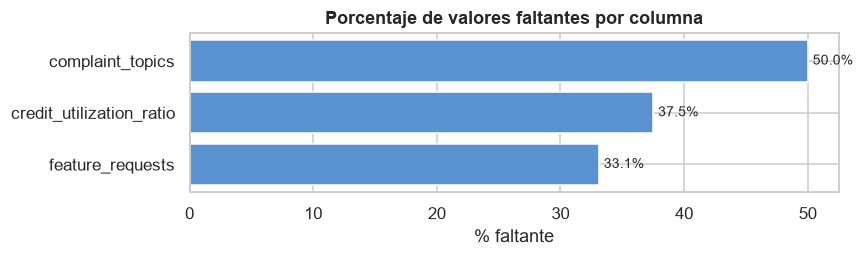

Filas duplicadas          : 0
customer_id duplicados    : 0



In [7]:
faltan = df.isna().sum()
faltan = faltan[faltan > 0].sort_values(ascending=False)
tabla = pd.DataFrame({'faltantes': faltan, '%': (faltan / len(df) * 100).round(1)})
print('Columnas con valores faltantes:')
print(tabla)

fig, ax = plt.subplots(figsize=(8, 0.5 * len(tabla) + 1))
ax.barh(tabla.index, tabla['%'], color=PAL[3])
ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_xlabel('% faltante'); ax.invert_yaxis()
for i, v in enumerate(tabla['%']): ax.text(v + 0.4, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('\nFilas duplicadas          :', df.duplicated().sum())
print('customer_id duplicados    :', df['customer_id'].duplicated().sum())

**Conclusión (sección 4).** Los faltantes se concentran en **solo tres columnas** —`complaint_topics` (50 %), `credit_utilization_ratio` (37,5 %) y `feature_requests` (33,1 %)— y el resto está prácticamente completo. **No hay filas ni `customer_id` duplicados.** Antes de imputar conviene entender *por qué* faltan (siguiente celda).

### 4.1 Faltantes: ¿aleatorios o estructurales?

In [8]:
# Relacionamos cada columna con faltantes con otra que explica el NaN
falta_cred = df['credit_utilization_ratio'].isna()
print(f"\ncredit_utilization_ratio  (faltan {falta_cred.mean()*100:.1f}%)  segun  credit_card:")
print(pd.crosstab(falta_cred, df['credit_card'], normalize='index').round(3).to_string())

for col, ref in [('complaint_topics', 'support_tickets_count'),
                 ('feature_requests', 'feature_usage_diversity')]:
    falta = df[col].isna()
    print(f'\n{col}  (faltan {falta.mean()*100:.1f}%)  segun  {ref}:')
    print('   media de ' + ref + ' | falta=False vs True:',
          df.groupby(falta)[ref].mean().round(2).to_dict())

# La AUSENCIA es informacion: creamos banderas has_*
for col in ['complaint_topics', 'feature_requests', 'credit_utilization_ratio']:
    df['has_' + col] = df[col].notna().astype(int)

credit_utilization_ratio  (faltan 37.5%)  segun  credit_card:
credit_card               False  True 
credit_utilization_ratio              
False                      0.00   1.00
True                       1.00   0.00

complaint_topics  (faltan 50.0%)  segun  support_tickets_count:
   media de support_tickets_count | falta=False vs True: {False: 1.0, True: 1.0}

feature_requests  (faltan 33.1%)  segun  feature_usage_diversity:
   media de feature_usage_diversity | falta=False vs True: {False: 2.37, True: 2.37}


**Conclusión.** El faltante de `credit_utilization_ratio` es **estructural**: la tabla de contingencia frente a `credit_card` es perfecta (el 100 % de los ausentes corresponde a clientes sin tarjeta), de modo que el `NaN` significa *"no aplica"* y no *"dato perdido"*. En cambio, `complaint_topics` y `feature_requests` no muestran relación con las variables de referencia examinadas, por lo que su ausencia se comporta como aproximadamente aleatoria. **Decisión:** crear banderas `has_*` que preserven la información de la ausencia e imputar 0 en la utilización de crédito únicamente a quienes tienen tarjeta; no imputar promedios, porque inventarían información.

### 4.2 Columnas de transacciones: ¿redundantes, escaladas o revueltas?
El dataset trae **dos grupos** de columnas que resumen las transacciones. La sección original mostró que no coinciden; aquí averiguamos **por qué**.

In [9]:
pares = [('total_tx_volume', 'total_transaction_volume'),
         ('avg_tx_value',     'average_transaction_value'),
         ('tx_count',         'monthly_transaction_count')]
for a, b in pares:
    ig = np.isclose(df[a].fillna(-1), df[b].fillna(-1))
    print(f'{a:22s} vs {b:26s}: {ig.mean()*100:5.1f}% de filas coinciden')

total_tx_volume        vs total_transaction_volume  :   0.0% de filas coinciden
avg_tx_value           vs average_transaction_value :   0.0% de filas coinciden
tx_count               vs monthly_transaction_count :   0.0% de filas coinciden



In [10]:
def relacion(a, b):
    x, y = df[a].astype(float), df[b].astype(float)
    ok = x.notna() & y.notna()
    alineadas = np.isclose(x[ok], y[ok]).mean() * 100                              # coincidencia fila a fila
    mismos = np.isclose(np.sort(x[ok].values), np.sort(y[ok].values)).mean() * 100  # como conjunto
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.nanmedian((y[ok] / x[ok]).replace([np.inf, -np.inf], np.nan))
    return alineadas, mismos, ratio

pares = [('avg_tx_value', 'average_transaction_value'),
         ('total_tx_volume', 'total_transaction_volume'),
         ('tx_count', 'monthly_transaction_count'),
         ('transaction_frequency', 'avg_daily_transactions')]
filas = []
for a, b in pares:
    al, mv, ratio = relacion(a, b)
    filas.append([a + ' / ' + b, round(al, 1), round(mv, 1), round(ratio, 3)])
tab_dup = pd.DataFrame(filas, columns=['par de columnas', 'coinciden_fila_%',
                                       'mismos_valores_%', 'ratio_b/a'])
display(tab_dup)

,par de columnas,coinciden_fila_%,mismos_valores_%,ratio_b/a
0,avg_tx_value / average_transaction_value,0.00,100.00,1.00
1,total_tx_volume / total_transaction_volume,0.00,100.00,0.99
2,tx_count / monthly_transaction_count,0.00,0.00,0.12
3,transaction_frequency / avg_daily_transactions,100.00,100.00,1.00


**Conclusión.** Dos pares comparten el **100 % de sus valores** pero **0 % de coincidencia fila a fila**: son la misma variable *revuelta* respecto del identificador de cliente, es decir, un duplicado corrupto y no una medida alternativa. El par `tx_count` / `monthly_transaction_count` sí corresponde a la misma magnitud en otra ventana temporal, y `transaction_frequency` ≡ `avg_daily_transactions` es un duplicado exacto. **Decisión:** conservar una sola columna de cada grupo; en la sección 9.3 se verifica cuál cuadra con las transacciones reales.

**Diagnóstico por par:**

| Par de columnas | Diagnóstico |
|---|---|
| `avg_tx_value` / `average_transaction_value` | Duplicado desalineado (misma variable revuelta) |
| `total_tx_volume` / `total_transaction_volume` | Duplicado desalineado (misma variable revuelta) |
| `tx_count` / `monthly_transaction_count` | Misma magnitud en otra ventana temporal |
| `transaction_frequency` / `avg_daily_transactions` | Duplicado exacto y alineado |

### 4.3 Rangos acotados y valores sospechosos

In [11]:
for c in ['age', 'churn_probability', 'customer_tenure', 'satisfaction_score']:
    s = df[c]
    print(f'{c:22s} min={s.min():>10.2f}  max={s.max():>12.2f}  '
          f'p1={s.quantile(.01):>10.2f}  p99={s.quantile(.99):>12.2f}')

z = int((df['customer_lifetime_value'] == 0).sum())
print(f'\ncustomer_lifetime_value == 0 (exacto): {z:,} clientes ({z/len(df)*100:.2f}%)')

age                    min=     29.00  max=       60.00  p1=     29.00  p99=       60.00
churn_probability      min=      0.11  max=        0.50  p1=      0.17  p99=        0.46
customer_tenure        min=      4.70  max=       11.97  p1=      8.63  p99=       11.97
satisfaction_score     min=      2.00  max=        6.00  p1=      3.00  p99=        5.00

customer_lifetime_value == 0 (exacto): 1 clientes (0.00%)


**Conclusión.** Varias variables presentan límites artificiales: `age` se restringe exactamente a 29–60 años, `customer_tenure` se satura en 11,97 y `churn_probability` se mueve solo entre 0,11 y 0,50. Que una *probabilidad* no alcance nunca 0 ni 1 indica que es un **puntaje ya calculado**, no un evento de fuga observado. Solo un cliente presenta CLV exactamente igual a cero (0,00 %), volumen irrelevante. **Implicación:** no extrapolar fuera de los rangos observados y auditar cómo se generó `churn` (sección 7.1).

**Conclusión (secciones 4.1–4.3).** Como podemos ver, `avg_tx_value`≡`average_transaction_value` y `total_tx_volume`≡`total_transaction_volume` tienen **estadísticos idénticos pero 0 % de coincidencia fila a fila**: son la misma variable *revuelta*, no dos medidas distintas (corrige la interpretación de "total histórico vs mensual"). En cambio `tx_count` (media 64,8 = 3.159.157 ⁄ 48.723) **sí** refleja las transacciones reales y `monthly_transaction_count` es su versión mensual. Varias variables están acotadas de forma artificial, lo que sugiere un dataset parcialmente sintético. Además, la prueba confirma un caso **idéntico y alineado**: `transaction_frequency` ≡ `avg_daily_transactions` (100 % de coincidencia), otro duplicado a descartar.

## 5. Análisis univariado
### 5.1 Variables numéricas

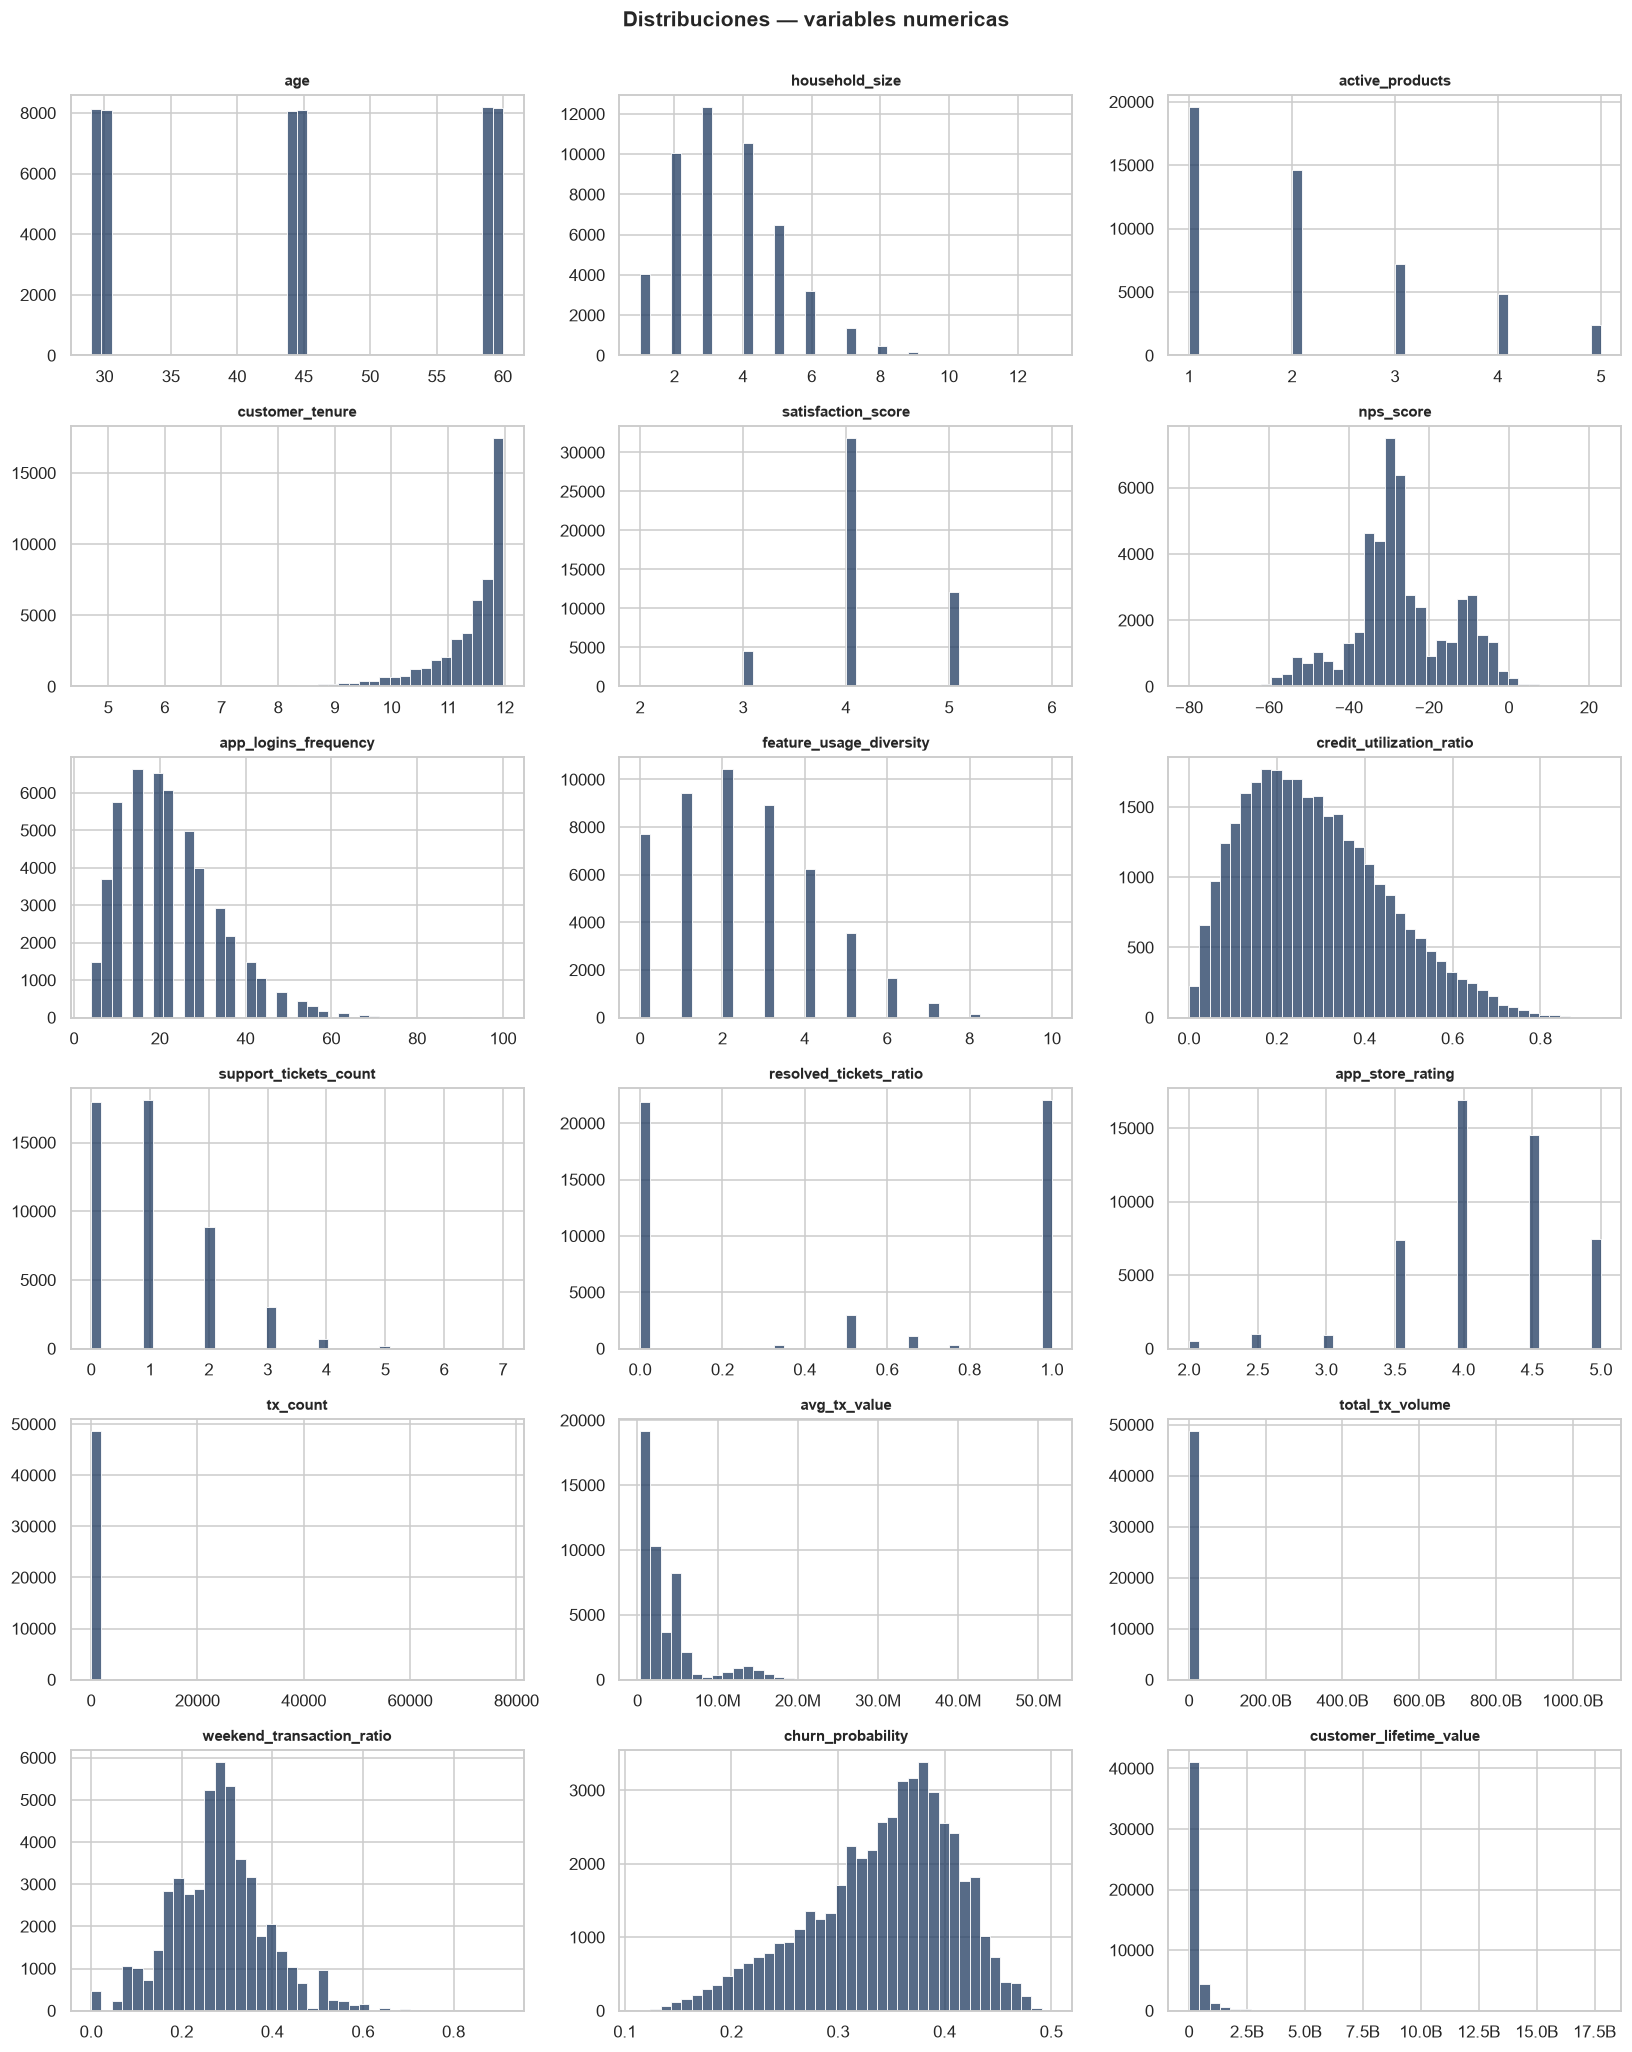

In [12]:
vars_num = ['age', 'household_size', 'active_products', 'customer_tenure',
            'satisfaction_score', 'nps_score', 'app_logins_frequency', 'feature_usage_diversity',
            'credit_utilization_ratio', 'support_tickets_count', 'resolved_tickets_ratio',
            'app_store_rating', 'tx_count', 'avg_tx_value', 'total_tx_volume',
            'weekend_transaction_ratio', 'churn_probability', 'customer_lifetime_value']

ncols = 3; nrows = int(np.ceil(len(vars_num) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.1 * nrows))
for ax, c in zip(axes.ravel(), vars_num):
    sns.histplot(df[c].dropna(), bins=40, ax=ax, color=PAL[0])
    ax.set_title(c, fontsize=10); ax.set_xlabel(''); ax.set_ylabel('')
    if df[c].max() > 1e6: ax.xaxis.set_major_formatter(FMT)
for ax in axes.ravel()[len(vars_num):]: ax.axis('off')
fig.suptitle('Distribuciones — variables numericas', y=1.002, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Las variables monetarias están muy sesgadas a la derecha; las vemos en escala logarítmica.

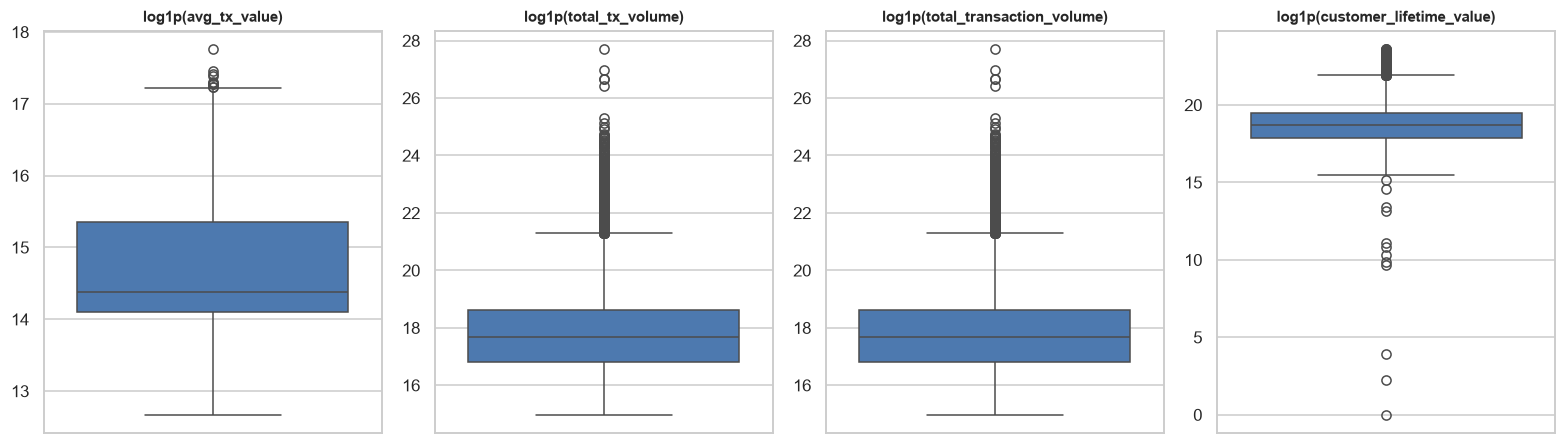

In [13]:
vars_log = ['avg_tx_value', 'total_tx_volume', 'total_transaction_volume', 'customer_lifetime_value']
fig, axes = plt.subplots(1, len(vars_log), figsize=(3.6 * len(vars_log), 4.2))
axes = np.atleast_1d(axes)
for ax, c in zip(axes, vars_log):
    sns.boxplot(y=np.log1p(df[c].clip(lower=0)), ax=ax, color=PAL[2])
    ax.set_title(f'log1p({c})', fontsize=10); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 5.2 Variables categóricas

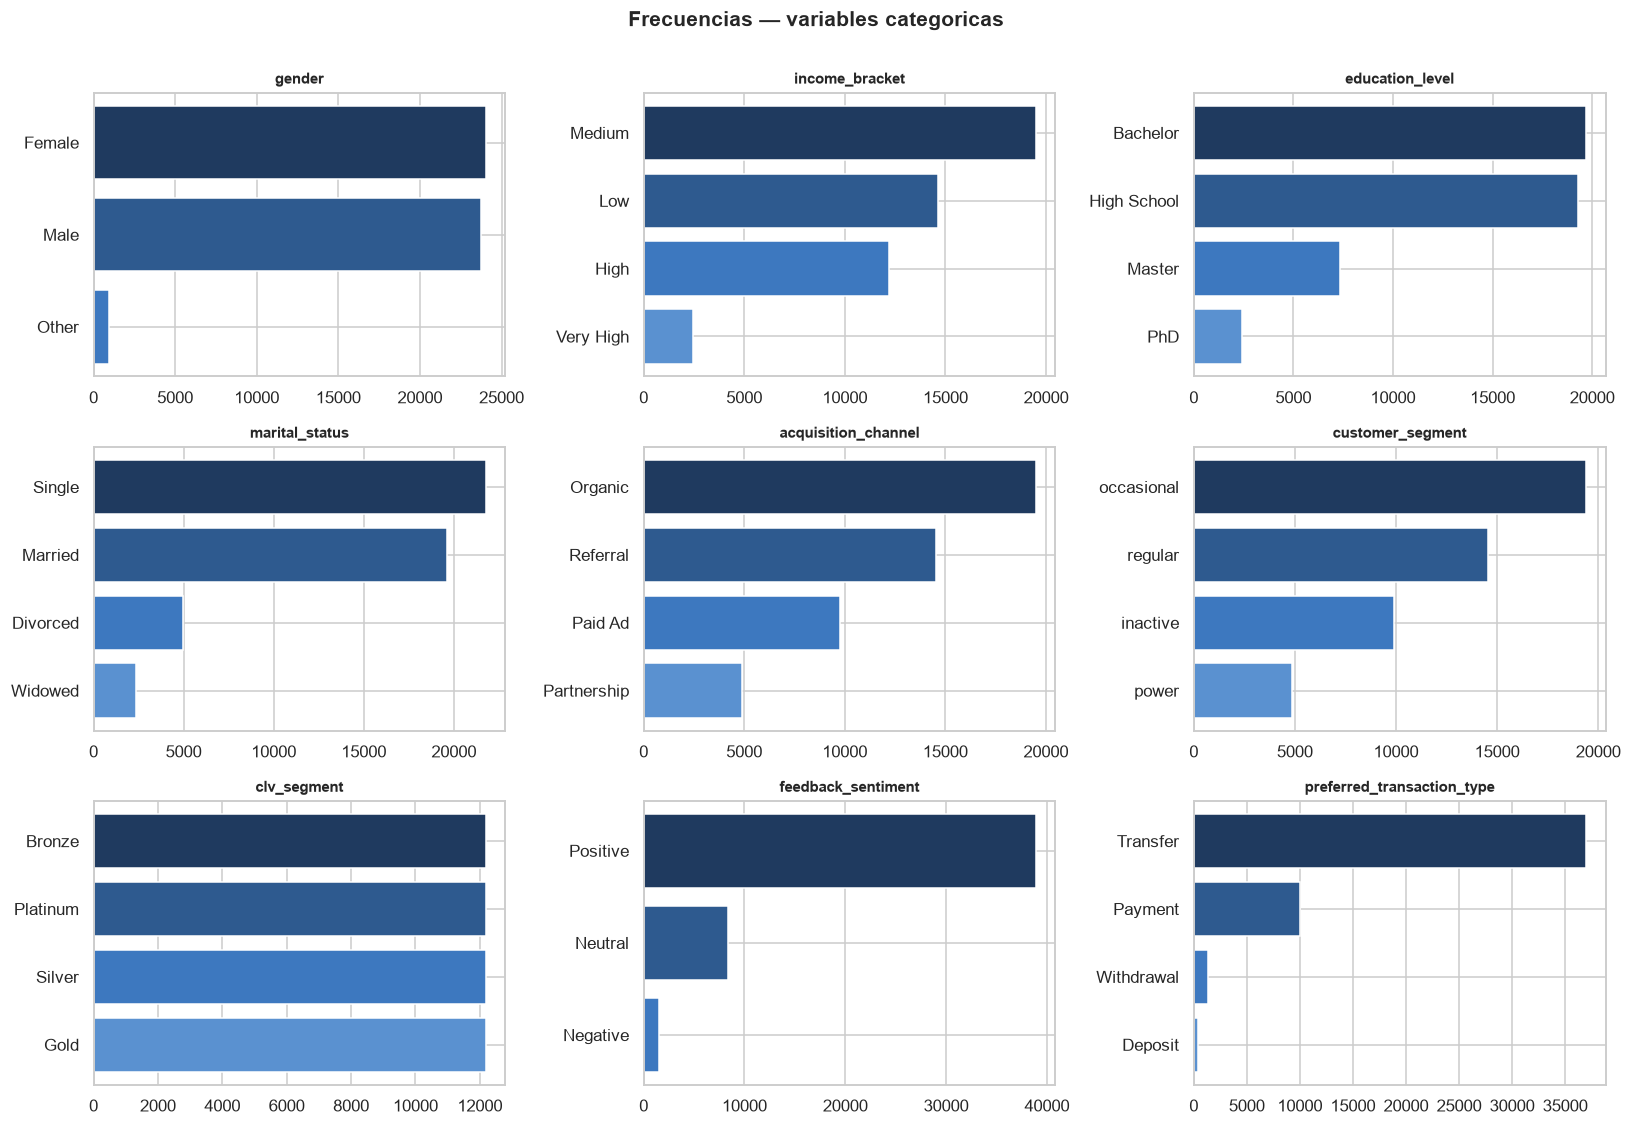

In [14]:
vars_cat = ['gender', 'income_bracket', 'education_level', 'marital_status',
            'acquisition_channel', 'customer_segment', 'clv_segment', 'feedback_sentiment',
            'preferred_transaction_type']

ncols = 3; nrows = int(np.ceil(len(vars_cat) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.4 * nrows))
for ax, c in zip(axes.ravel(), vars_cat):
    vc = df[c].value_counts()
    ax.barh(vc.index.astype(str), vc.values, color=PAL[:len(vc)])
    ax.set_title(c, fontsize=10); ax.invert_yaxis()
for ax in axes.ravel()[len(vars_cat):]: ax.axis('off')
fig.suptitle('Frecuencias — variables categoricas', y=1.002, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

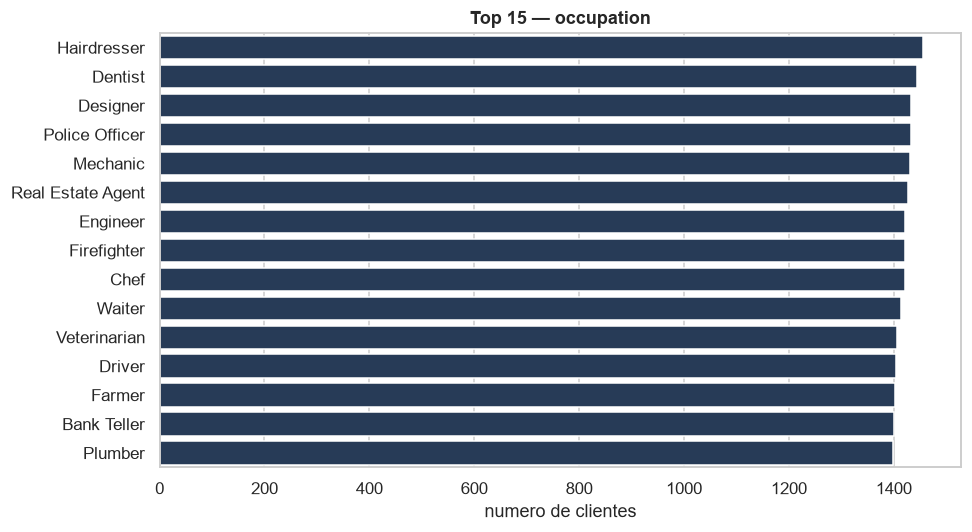

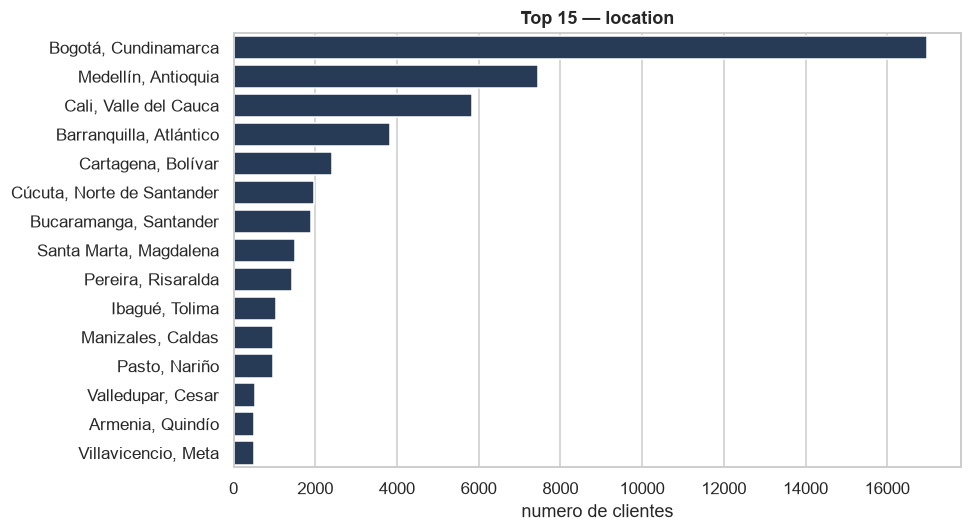

In [15]:
# Categoricas con muchos niveles: top 15
for c in ['occupation', 'location']:
    vc = df[c].value_counts().head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=vc.values, y=vc.index.astype(str), color=AZUL)
    plt.title(f'Top 15 — {c}'); plt.xlabel('numero de clientes'); plt.ylabel('')
    plt.tight_layout(); plt.show()

### 5.3 Tenencia y adopción de productos

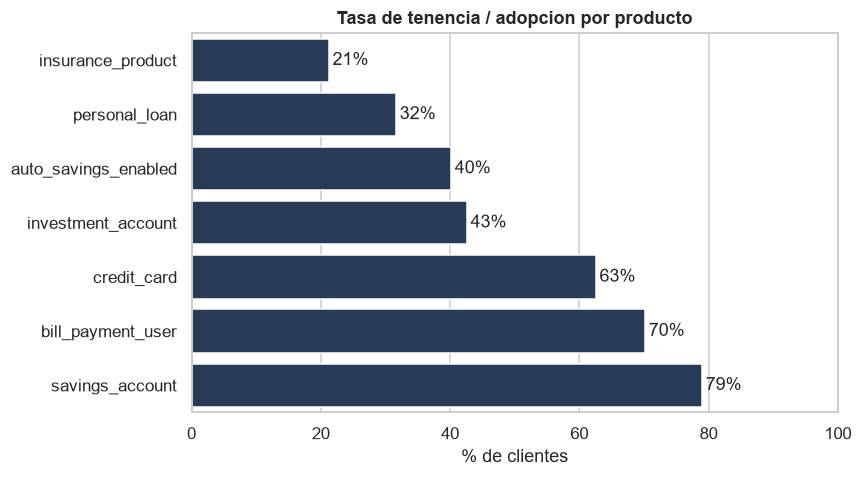

In [16]:
prod = ['savings_account', 'credit_card', 'personal_loan', 'investment_account',
        'insurance_product', 'bill_payment_user', 'auto_savings_enabled']
tasas = (df[prod].mean() * 100).sort_values()
plt.figure(figsize=(8, 4.5))
sns.barplot(x=tasas.values, y=tasas.index, color=AZUL)
for i, v in enumerate(tasas.values): plt.text(v + 0.6, i, f'{v:.0f}%', va='center')
plt.title('Tasa de tenencia / adopcion por producto'); plt.xlabel('% de clientes'); plt.ylabel('')
plt.xlim(0, 100); plt.tight_layout(); plt.show()

### 5.4 Cuantificación de *outliers* (regla IQR 1,5×)
Los diagramas de caja muestran los atípicos; aquí los **contamos**.

In [17]:
filas = []
for c in col_num:
    n, pct, lo, hi = outliers_iqr(df[c])
    filas.append((c, n, pct, round(lo, 2), round(hi, 2)))
tab_out = (pd.DataFrame(filas, columns=['variable', 'n_outliers', '%', 'lim_inf', 'lim_sup'])
             .sort_values('%', ascending=False).reset_index(drop=True))
display(tab_out.head(15))

peor = tab_out.iloc[0]

,variable,n_outliers,%,lim_inf,lim_sup
0,failed_transactions,8818,18.10,0.00,0.00
1,monthly_transaction_count,6394,13.10,-0.64,5.33
2,transaction_frequency,5889,12.10,-0.05,0.20
3,avg_daily_transactions,5889,12.10,-0.05,0.20
4,tx_satisfaction,5783,11.90,-0.11,0.35
5,tx_count,5783,11.90,-22.50,69.50
6,total_tx_volume,5379,11.00,"-130,271,375.00","270,874,825.00"
7,total_transaction_volume,5379,11.00,"-130,271,375.00","270,874,825.00"
8,customer_lifetime_value,4811,9.90,"-299,997,892.00","655,768,175.53"
9,average_transaction_value,4602,9.40,"-3,640,018.33","9,637,669.18"


**Conclusión.** Los atípicos se concentran en variables de conteo y monetarias, encabezadas por `failed_transactions` (18,1 %), `monthly_transaction_count` (13,1 %) y `transaction_frequency` (12,1 %). No son errores de captura sino **colas legítimas** de distribuciones asimétricas: en `failed_transactions` la mediana y ambos cuartiles valen cero, de modo que cualquier cliente con una sola incidencia queda marcado por construcción de la regla. **Decisión:** conservarlos y aplicar transformación logarítmica a las variables monetarias, en lugar de eliminar filas.

**Conclusión (sección 5).** Las distribuciones numéricas confirman **fuerte asimetría a la derecha** en `total_tx_volume`, `avg_tx_value` y `customer_lifetime_value` (de ahí que sus *outliers* por IQR sean tan numerosos): son colas legítimas, no errores, y piden **transformación logarítmica** antes de modelar. `age` se concentra en 29–30 y luego se reparte hasta 60. En categóricas, `Transfer` domina el tipo de transacción preferido y la adopción de productos es desigual (unos pocos productos concentran la tenencia). El recuento por IQR sitúa a la cabeza a `failed_transactions` (18,1 % de atípicos), `monthly_transaction_count` (13,1 %) y `transaction_frequency` (12,1 %).

## 6. Relaciones entre variables numéricas
Matriz de correlación (Pearson) y variables más asociadas a cada objetivo.

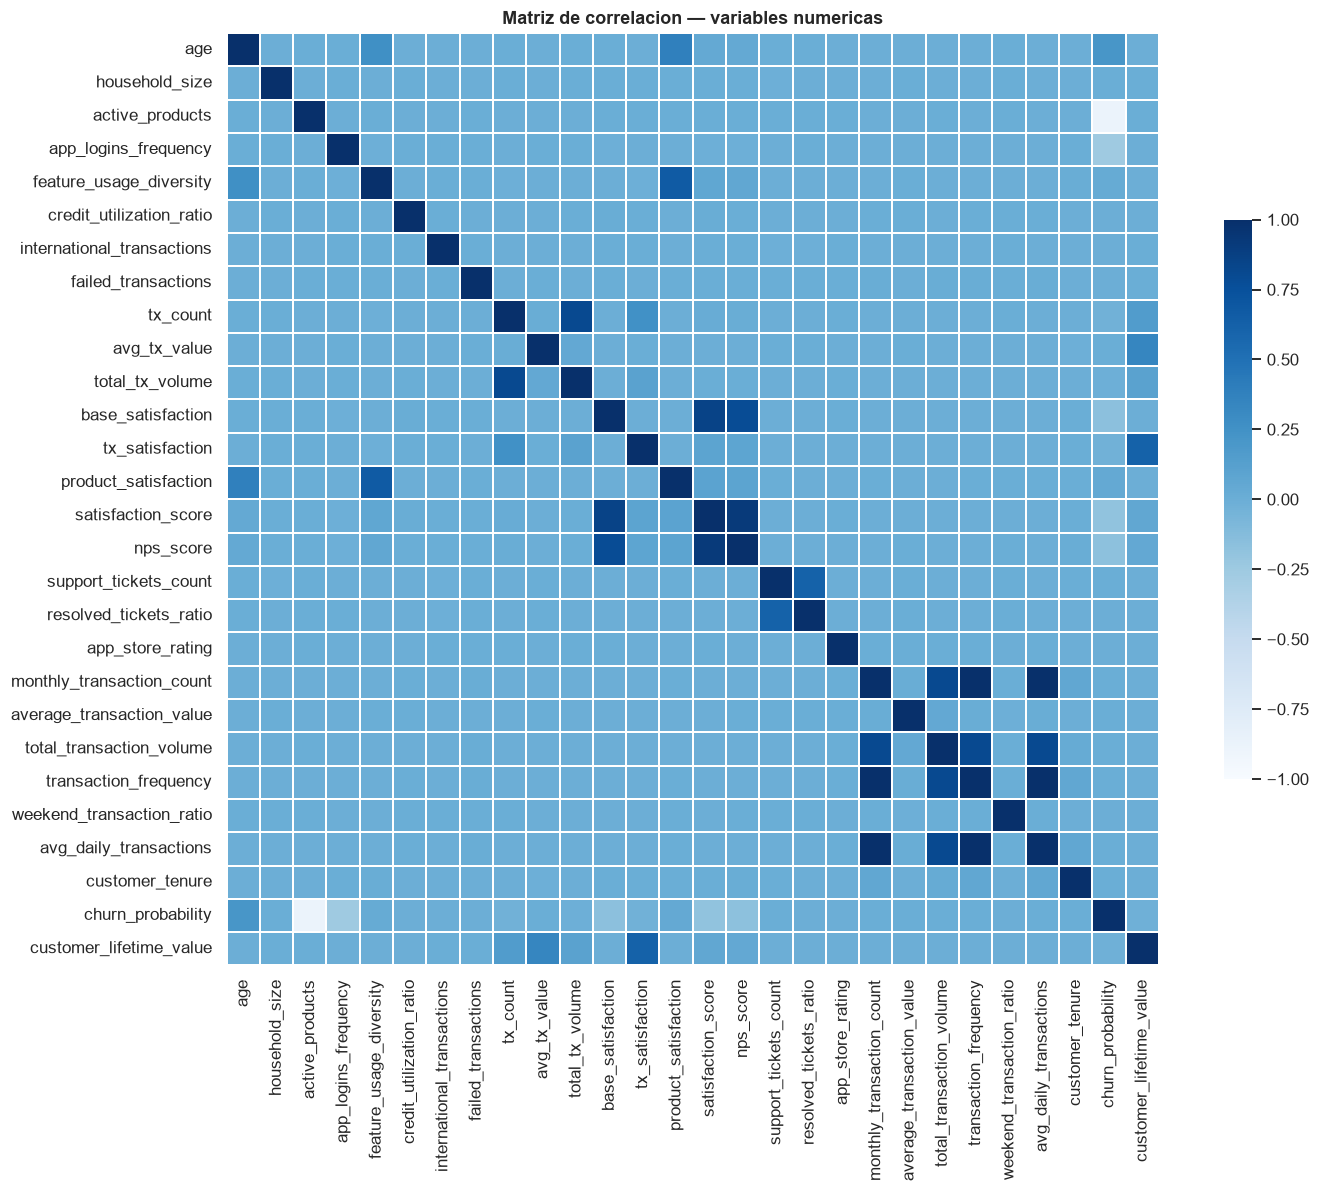

Top correlaciones (|r|) con churn_probability:
active_products           -0.88
app_logins_frequency      -0.26
age                        0.21
satisfaction_score        -0.18
nps_score                 -0.17
base_satisfaction         -0.16
product_satisfaction       0.04
feature_usage_diversity    0.03

Top correlaciones (|r|) con customer_lifetime_value:
tx_satisfaction       0.61
avg_tx_value          0.34
tx_count              0.16
total_tx_volume       0.11
satisfaction_score    0.06
nps_score             0.05
churn_probability    -0.02
app_store_rating     -0.01



In [18]:
corr = df[col_num].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='Blues', vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={'shrink': 0.6})
plt.title('Matriz de correlacion — variables numericas'); plt.tight_layout(); plt.show()

for obj in ['churn_probability', 'customer_lifetime_value']:
    top = corr[obj].drop(obj).abs().sort_values(ascending=False).head(8)
    print(f'\nTop correlaciones (|r|) con {obj}:')
    print(corr[obj].loc[top.index].round(3).to_string())

### 6.1 Spearman vs Pearson en variables sesgadas

In [19]:
for obj in ['churn_probability', 'customer_lifetime_value']:
    p = df[col_num].corr('pearson')[obj].drop(obj)
    s = df[col_num].corr('spearman')[obj].drop(obj)
    comp = pd.DataFrame({'pearson': p, 'spearman': s})
    top = comp.reindex(comp['spearman'].abs().sort_values(ascending=False).index).head(6)
    print(f'Top asociaciones con {obj} (por |Spearman|):')
    display(top.round(3))

Top asociaciones con churn_probability (por |Spearman|):



,pearson,spearman
active_products,-0.88,-0.84
app_logins_frequency,-0.26,-0.28
age,0.21,0.21
satisfaction_score,-0.18,-0.19
base_satisfaction,-0.16,-0.16
nps_score,-0.17,-0.16


Top asociaciones con customer_lifetime_value (por |Spearman|):



,pearson,spearman
total_tx_volume,0.11,0.98
avg_tx_value,0.34,0.76
tx_satisfaction,0.61,0.56
tx_count,0.16,0.56
satisfaction_score,0.06,0.05
nps_score,0.05,0.04


**Conclusión.** El contraste es decisivo para el CLV: su correlación de Pearson con `total_tx_volume` es de apenas **0,11**, pero la de **Spearman asciende a 0,98**, es decir, una relación monótona casi perfecta que Pearson no detecta por la extrema asimetría de ambas variables. Evaluar la asociación solo con Pearson habría llevado a descartar el mejor predictor disponible. **Decisión:** trabajar los montos en escala logarítmica, donde esa relación se vuelve aprovechable por modelos lineales.

### 6.2 Pares numéricos casi redundantes (|r| > 0,9)

In [20]:
corr_abs = df[col_num].corr().abs()
pares_red = (corr_abs.where(np.triu(np.ones(corr_abs.shape), 1).astype(bool))
                     .stack().sort_values(ascending=False))
altos = pares_red[pares_red > 0.9]
for (a, b), r in altos.items():
    print(f'  r={r:.3f}   {a}  <->  {b}')

  r=1.000   transaction_frequency  <->  avg_daily_transactions
  r=1.000   monthly_transaction_count  <->  avg_daily_transactions
  r=1.000   monthly_transaction_count  <->  transaction_frequency
  r=0.917   satisfaction_score  <->  nps_score


**Conclusión.** Se detecta un bloque de **tres variables mutuamente idénticas** (`monthly_transaction_count`, `transaction_frequency` y `avg_daily_transactions`, con r = 1,000 entre sí) y un par de satisfacción fuertemente asociado (`satisfaction_score` y `nps_score`, r = 0,917). Esta redundancia infla la varianza de los coeficientes en modelos lineales. **Decisión:** conservar una sola variable de cada grupo.

### 6.3 Asociación entre variables categóricas (Cramér's V)

In [21]:
cats = ['gender', 'income_bracket', 'education_level', 'marital_status',
        'acquisition_channel', 'customer_segment', 'clv_segment', 'feedback_sentiment',
        'preferred_transaction_type']
V = pd.DataFrame(index=cats, columns=cats, dtype=float)
for a in cats:
    for b in cats:
        V.loc[a, b] = 1.0 if a == b else cramers_v(df[a], df[b])
display(V.round(2))

mask = ~np.eye(len(cats), dtype=bool)
mx = V.where(mask).stack().astype(float)
(pa, pb), val = mx.idxmax(), mx.max()

,gender,income_bracket,education_level,marital_status,acquisition_channel,customer_segment,clv_segment,feedback_sentiment,preferred_transaction_type
gender,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
income_bracket,0.00,1.00,0.38,0.00,0.00,0.01,0.01,0.01,0.00
education_level,0.00,0.38,1.00,0.00,0.01,0.01,0.00,0.01,0.00
marital_status,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
acquisition_channel,0.00,0.00,0.01,0.00,1.00,0.00,0.00,0.00,0.01
customer_segment,0.00,0.01,0.01,0.00,0.00,1.00,0.38,0.00,0.01
clv_segment,0.00,0.01,0.00,0.00,0.00,0.38,1.00,0.00,0.01
feedback_sentiment,0.00,0.01,0.01,0.00,0.00,0.00,0.00,1.00,0.01
preferred_transaction_type,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.01,1.00


**Conclusión.** La asociación entre categóricas es baja en general, con dos excepciones moderadas: `customer_segment` ↔ `clv_segment` y `income_bracket` ↔ `education_level`, ambas con V = 0,38. La primera es esperable, pues las dos describen la intensidad de la relación comercial. El resto de los pares presenta valores cercanos a cero, lo que indica independencia y **descarta redundancia** entre las variables categóricas.

**Conclusión (sección 6).** Como podemos ver, el predictor **dominante de `churn` es `active_products` (r = −0,88)**; el resto (logins, edad, satisfacción, NPS) queda por debajo de |0,3|. Para `customer_lifetime_value` mandan `tx_satisfaction` (0,61) y `avg_tx_value` (0,34). Spearman confirma estas relaciones y, en las monetarias, suele superar a Pearson (relación monótona pero curva). La revisión de |r| > 0,9 delata los duplicados detectados en 4.2.

## 7. Objetivo 1 — Probabilidad de fuga (`churn_probability`)

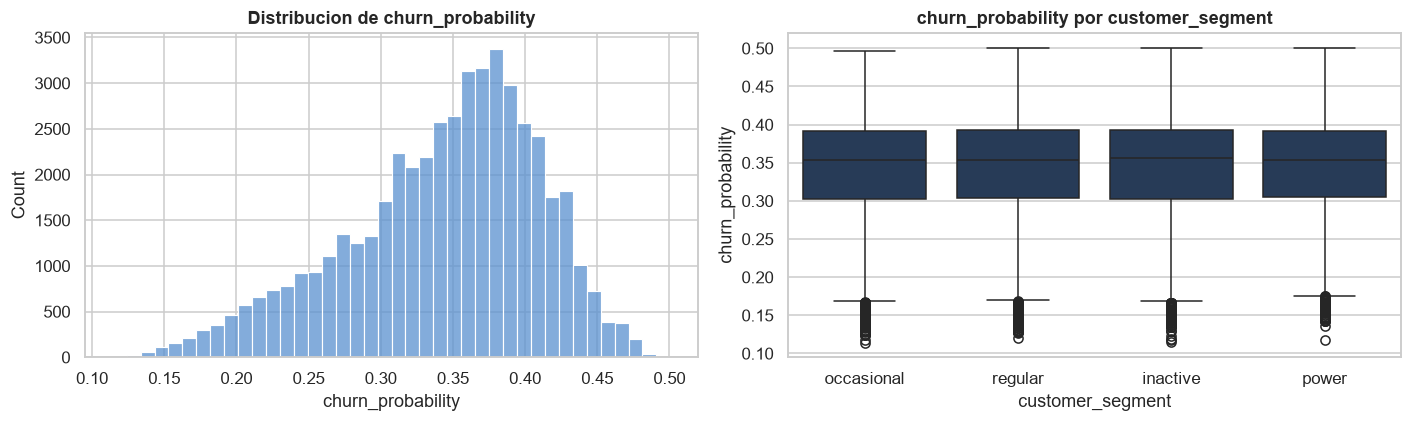

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['churn_probability'], bins=40, ax=axes[0], color=PAL[3])
axes[0].set_title('Distribucion de churn_probability'); axes[0].set_xlabel('churn_probability')
sns.boxplot(data=df, x='customer_segment', y='churn_probability', ax=axes[1], color=AZUL)
axes[1].set_title('churn_probability por customer_segment')
plt.tight_layout(); plt.show()

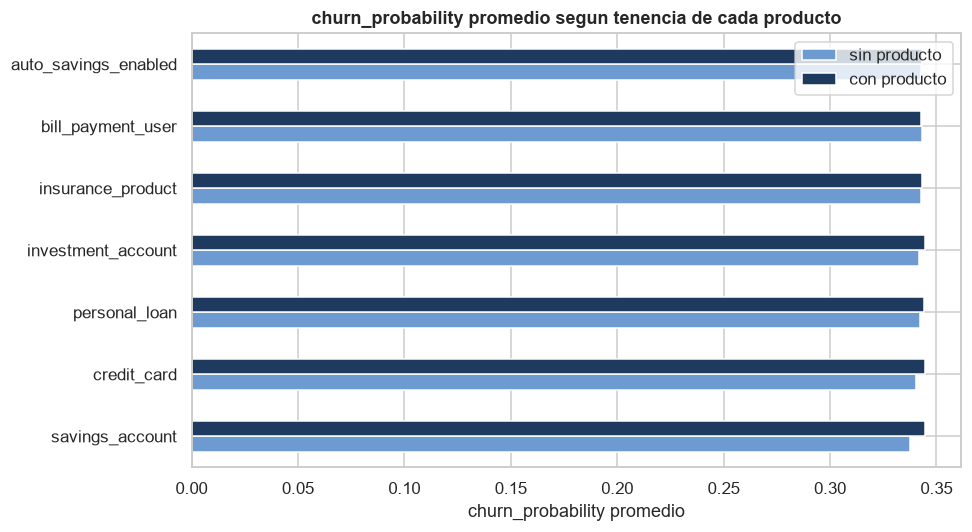

In [23]:
# churn promedio segun la tenencia de cada producto
med = {c: [df.loc[~df[c], 'churn_probability'].mean(),
           df.loc[df[c],  'churn_probability'].mean()] for c in prod}
mm = pd.DataFrame(med, index=['sin producto', 'con producto']).T
ax = mm.plot(kind='barh', figsize=(9, 5), color=[PAL[7], PAL[0]])
ax.set_title('churn_probability promedio segun tenencia de cada producto')
ax.set_xlabel('churn_probability promedio'); ax.legend(title='')
plt.tight_layout(); plt.show()

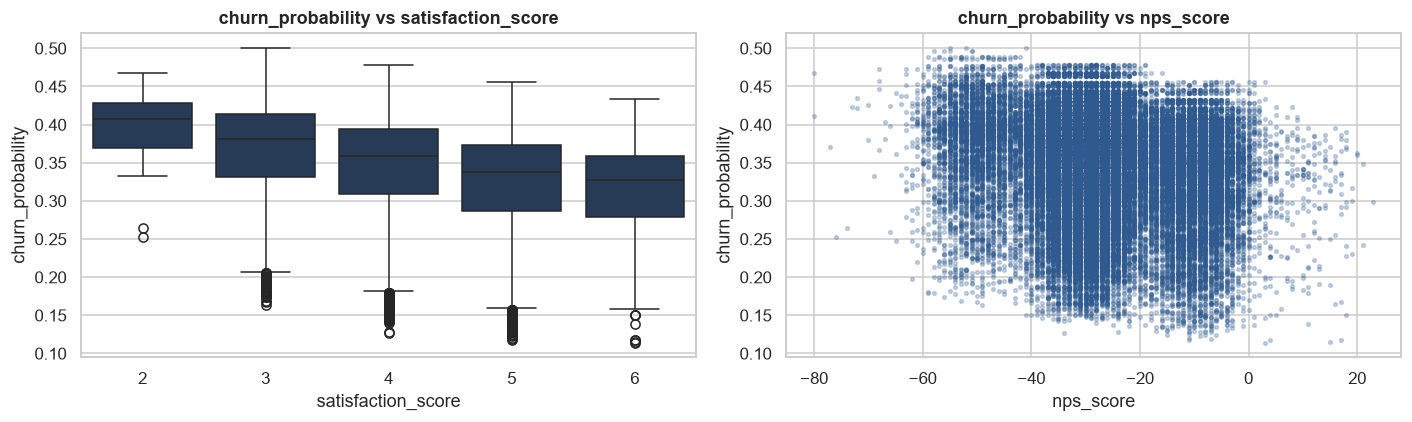

In [24]:
# churn frente a satisfaccion y a NPS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='satisfaction_score', y='churn_probability', ax=axes[0], color=AZUL)
axes[0].set_title('churn_probability vs satisfaction_score')
axes[1].scatter(df['nps_score'], df['churn_probability'], s=6, alpha=0.25, color=PAL[1])
axes[1].set_xlabel('nps_score'); axes[1].set_ylabel('churn_probability')
axes[1].set_title('churn_probability vs nps_score')
plt.tight_layout(); plt.show()

### 7.1 ¿Es `churn` una función de `active_products`? (posible fuga de datos)
La correlación de −0,88 es tan alta que conviene mirarla de cerca **antes de modelar**.

In [25]:
r = df[['active_products', 'churn_probability']].corr().iloc[0, 1]
print(f'Correlacion churn ~ active_products : r = {r:.3f}   ->   R^2 = {r**2:.3f}')
print('churn_probability por numero de productos activos:')
g = df.groupby('active_products')['churn_probability'].agg(['mean', 'std', 'count'])
display(g.round(3))
caida = g['mean'].diff().dropna()
print(f'\nCada producto adicional cambia el churn medio en {caida.mean():+.3f} (escalon casi constante).')

Correlacion churn ~ active_products : r = -0.876   ->   R^2 = 0.767
churn_probability por numero de productos activos:



,mean,std,count
active_products,,,
1,0.40,0.03,19576
2,0.35,0.03,14653
3,0.30,0.03,7197
4,0.25,0.03,4871
5,0.20,0.03,2426


Cada producto adicional cambia el churn medio en -0.050 (escalon casi constante).


**Conclusión — hallazgo crítico.** La fuga está **casi determinada** por `active_products`: r = −0,876, de modo que un único predictor explica el **76,7 %** de su varianza. Además, la relación es una **escalera de paso exactamente constante** (−0,05 por producto) con desviación estándar idéntica (0,03) en los cinco grupos. Una regularidad así no es propia de un fenómeno de comportamiento observado, en el que cabría esperar efectos decrecientes y varianza heterogénea. Todo indica que `churn_probability` fue **generada** a partir de `active_products` mediante una regla determinista más ruido.

**Riesgo de fuga de información:** un modelo que incluya `active_products` mostraría métricas excelentes que no reflejarían capacidad predictiva real, sino la recuperación de la fórmula generadora. **Decisión:** auditar la construcción de la etiqueta y reportar el desempeño con y sin esa variable.

### 7.2 `churn` según variables categóricas (tamaño de efecto eta²)

In [26]:
cats_obj = ['acquisition_channel', 'income_bracket', 'customer_segment',
            'location', 'education_level', 'preferred_transaction_type']
ef = sorted(((c, eta2(df[c], df['churn_probability'])) for c in cats_obj),
            key=lambda t: t[1], reverse=True)
for c, e in ef:
    print(f'  eta^2 = {e:.4f}   {c}')

top_cat = ef[0][0]
print(f'\nchurn promedio por {top_cat}:')
print(df.groupby(top_cat)['churn_probability'].mean().sort_values(ascending=False).round(3).to_string())

  eta^2 = 0.0050   income_bracket
  eta^2 = 0.0004   location
  eta^2 = 0.0002   education_level
  eta^2 = 0.0001   preferred_transaction_type
  eta^2 = 0.0001   customer_segment
  eta^2 = 0.0000   acquisition_channel

churn promedio por income_bracket:
income_bracket
Very High   0.35
High        0.35
Medium      0.34
Low         0.34


**Conclusión.** El tamaño de efecto η² mide qué fracción de la varianza de la fuga explica cada variable categórica. Ninguna supera el **0,5 %** (`income_bracket` encabeza con 0,0050), lo que confirma que el perfil demográfico, la ubicación y el canal de adquisición aportan una **señal marginal** frente al número de productos activos.

**Conclusión (sección 7).** El churn está **casi determinado por `active_products`** (R² = 0,767 con r = −0,876; escalón casi constante): es la señal más importante *y* la más sospechosa, porque apunta a una etiqueta construida a partir de esa variable. La satisfacción, el NPS y el *engagement* aportan una señal débil pero coherente (a más satisfacción/NPS, menos churn). Las categóricas explican poca varianza (eta² bajo). Para el modelo: binarizar `churn`, tratar `active_products` con cuidado por la posible fuga y validar la construcción de la etiqueta.

## 8. Objetivo 2 — Valor del cliente (`customer_lifetime_value` / `clv_segment`)

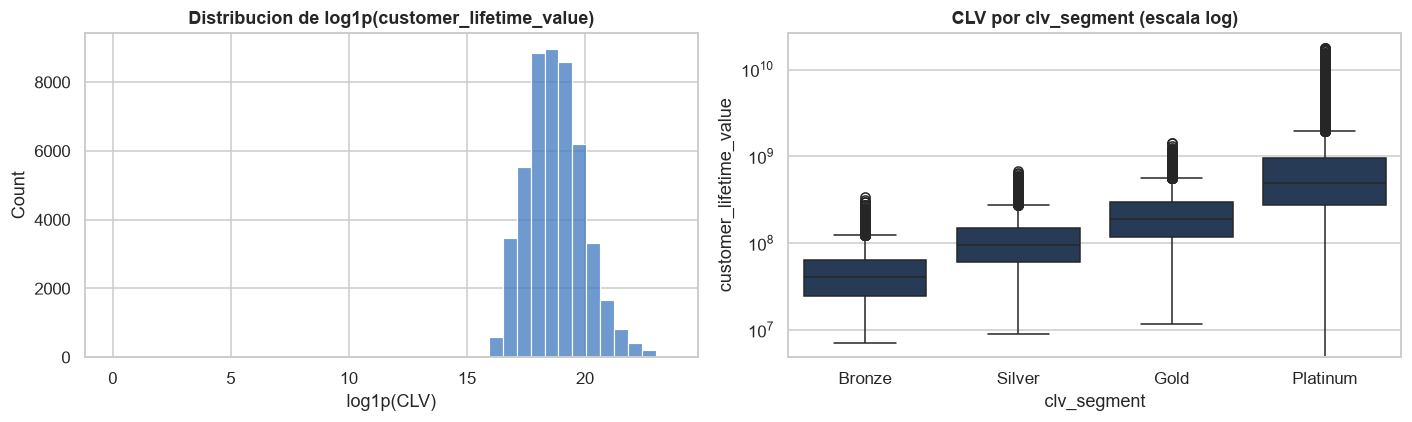

In [27]:
clv = 'customer_lifetime_value'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(np.log1p(df[clv]), bins=40, ax=axes[0], color=PAL[2])
axes[0].set_title('Distribucion de log1p(customer_lifetime_value)'); axes[0].set_xlabel('log1p(CLV)')
orden = ['Bronze', 'Silver', 'Gold', 'Platinum']
sns.boxplot(data=df, x='clv_segment', y=clv, order=orden, ax=axes[1], color=AZUL)
axes[1].set_yscale('log'); axes[1].set_title('CLV por clv_segment (escala log)')
plt.tight_layout(); plt.show()

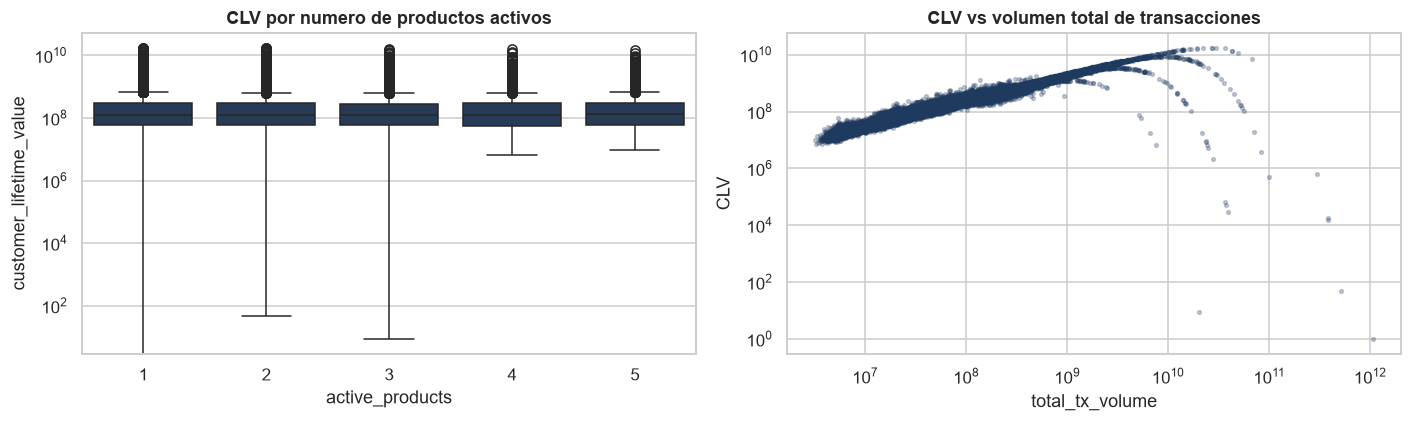

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='active_products', y=clv, ax=axes[0], color=AZUL)
axes[0].set_yscale('log'); axes[0].set_title('CLV por numero de productos activos')
axes[1].scatter(df['total_tx_volume'].clip(lower=1), df[clv].clip(lower=1),
                s=6, alpha=0.25, color=PAL[0])
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('total_tx_volume'); axes[1].set_ylabel('CLV')
axes[1].set_title('CLV vs volumen total de transacciones')
plt.tight_layout(); plt.show()

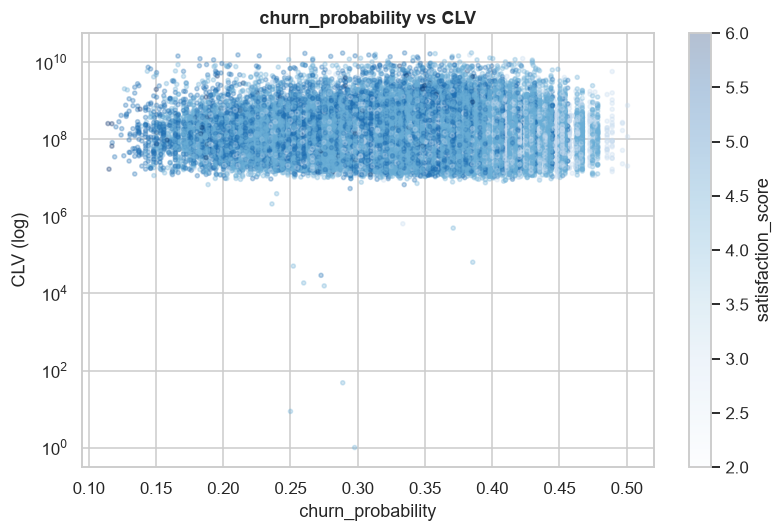

In [29]:
# Relacion entre los dos objetivos: churn vs CLV
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(df['churn_probability'], df[clv].clip(lower=1),
                 s=7, alpha=0.3, c=df['satisfaction_score'], cmap='Blues')
plt.yscale('log'); plt.xlabel('churn_probability'); plt.ylabel('CLV (log)')
plt.title('churn_probability vs CLV')
plt.colorbar(sc, label='satisfaction_score')
plt.tight_layout(); plt.show()

### 8.1 Drivers de CLV y clientes de valor cero

In [30]:
clv = 'customer_lifetime_value'
for c in ['clv_segment', 'active_products', 'customer_segment']:
    print(f'\nCLV mediana por {c}:')
    print(df.groupby(c)[clv].median().round(0).to_string())

e = eta2(df['clv_segment'], df[clv])
z = (df[clv] == 0).mean() * 100
print(f'\neta^2(clv_segment -> CLV) = {e:.3f}   |   clientes con CLV=0: {z:.2f}%')

CLV mediana por clv_segment:
clv_segment
Bronze      41,085,092.00
Gold       191,092,968.00
Platinum   492,539,268.00
Silver      95,773,233.00

CLV mediana por active_products:
active_products
1   129,183,095.00
2   129,741,109.00
3   128,860,357.00
4   129,386,883.00
5   137,615,269.00

CLV mediana por customer_segment:
customer_segment
inactive      31,452,136.00
occasional    87,991,123.00
power        534,097,996.00
regular      236,107,008.00

eta^2(clv_segment -> CLV) = 0.194   |   clientes con CLV=0: 0.00%


**Conclusión.** El CLV crece de forma **monótona y de gran amplitud** con `clv_segment` (de 4,11 × 10⁷ en *Bronze* a 4,93 × 10⁸ en *Platinum*, con η² = 0,194) y con `customer_segment` (de 3,15 × 10⁷ en clientes inactivos a 5,34 × 10⁸ en los más activos). En cambio, **no varía con el número de productos activos**: permanece en torno a 1,29 × 10⁸ entre uno y cuatro productos. Es decir, la variable que casi determina la fuga **no guarda relación con el valor del cliente**; este se explica por la intensidad transaccional. Ambos objetivos responden, por tanto, a mecanismos distintos.

**Conclusión (sección 8).** El CLV está **fuertemente sesgado** (mediana ≈ 129,7 M vs media ≈ 328,2 M COP) y **crece de forma ordenada** con `clv_segment` y con el número de productos activos: el segmento es un buen resumen del valor. Conviene modelarlo en escala logarítmica y decidir qué hacer con los clientes de CLV = 0.

## 9. Análisis de las transacciones (`transactions_data.csv`)
Comportamiento por transacción: montos por tipo, evolución temporal y agregación por cliente.

In [31]:
print('Estructura:'); print(tx.dtypes.to_string())
print('\nRango de fechas:', tx['date'].min().date(), '->', tx['date'].max().date())
print('Transacciones :', f'{len(tx):,}   |   clientes distintos: {tx.customer_id.nunique():,}')
print('\nPor tipo:'); print(tx['type'].value_counts().to_string())
display(tx.head())

Estructura:
customer_id             int64
date           datetime64[us]
amount                  int64
type                      str

Rango de fechas: 2023-01-04 -> 2023-12-29
Transacciones : 3,159,157   |   clientes distintos: 48,723

Por tipo:



type
Transfer      1433963
Payment        970548
Withdrawal     456577
Deposit        298069



,customer_id,date,amount,type
0,93716481,2023-11-23,1262800,Transfer
1,93716481,2023-01-05,928900,Withdrawal
2,93716481,2023-11-05,1683100,Payment
3,93716481,2023-04-14,4507350,Payment
4,93716481,2023-08-04,2096150,Payment


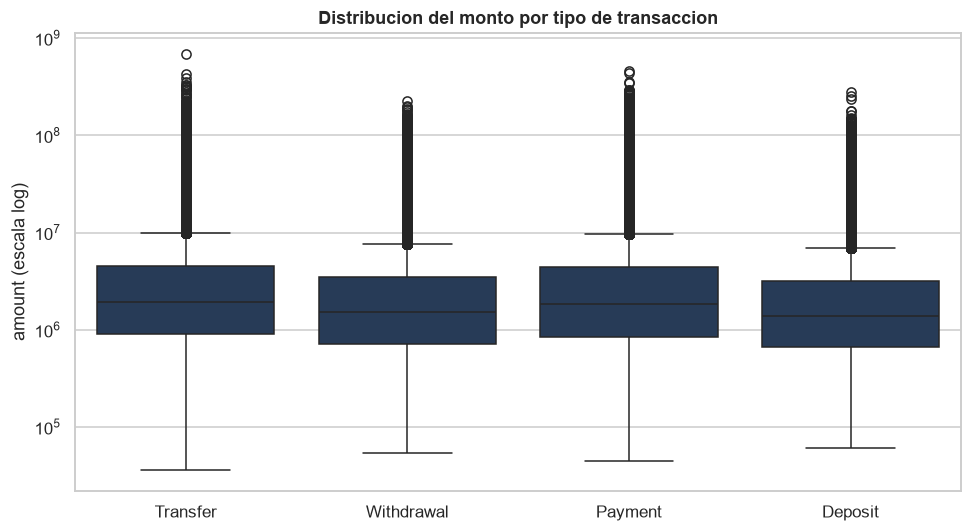

In [32]:
# Distribucion del monto por tipo de transaccion (escala log)
plt.figure(figsize=(9, 5))
sns.boxplot(data=tx, x='type', y='amount', color=AZUL)
plt.yscale('log'); plt.title('Distribucion del monto por tipo de transaccion')
plt.ylabel('amount (escala log)'); plt.xlabel('')
plt.tight_layout(); plt.show()

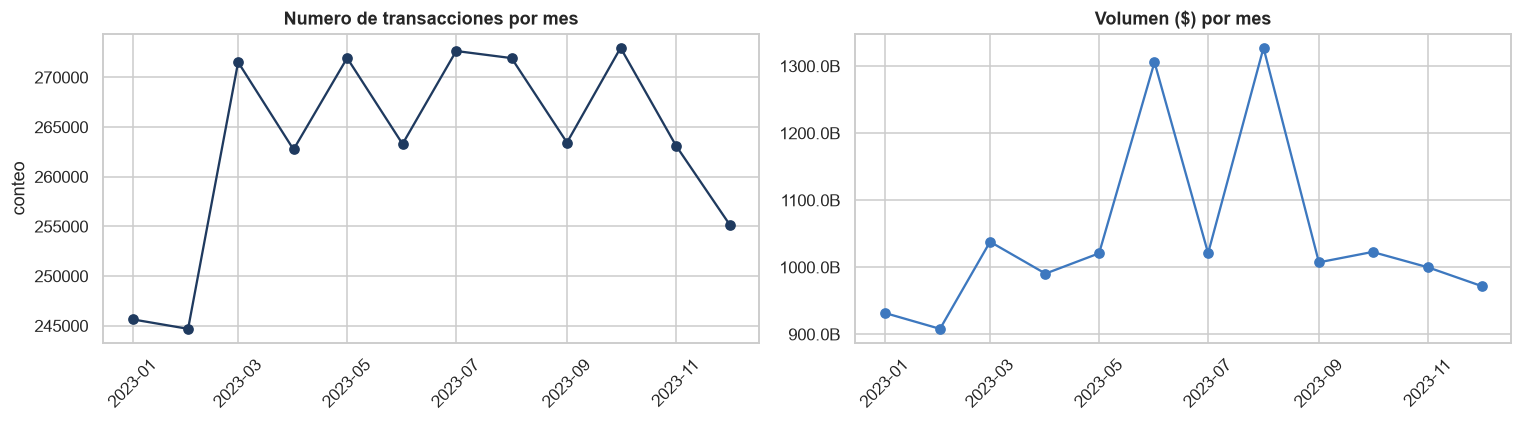

In [33]:
# Evolucion temporal: numero de transacciones y volumen por mes
tx['mes'] = tx['date'].dt.to_period('M').dt.to_timestamp()
serie = tx.groupby('mes').agg(n=('amount', 'size'), volumen=('amount', 'sum'))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(serie.index, serie['n'], marker='o', color=PAL[0])
ax[0].set_title('Numero de transacciones por mes'); ax[0].set_ylabel('conteo')
ax[1].plot(serie.index, serie['volumen'], marker='o', color=PAL[2])
ax[1].set_title('Volumen ($) por mes'); ax[1].yaxis.set_major_formatter(FMT)
for a in ax: a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

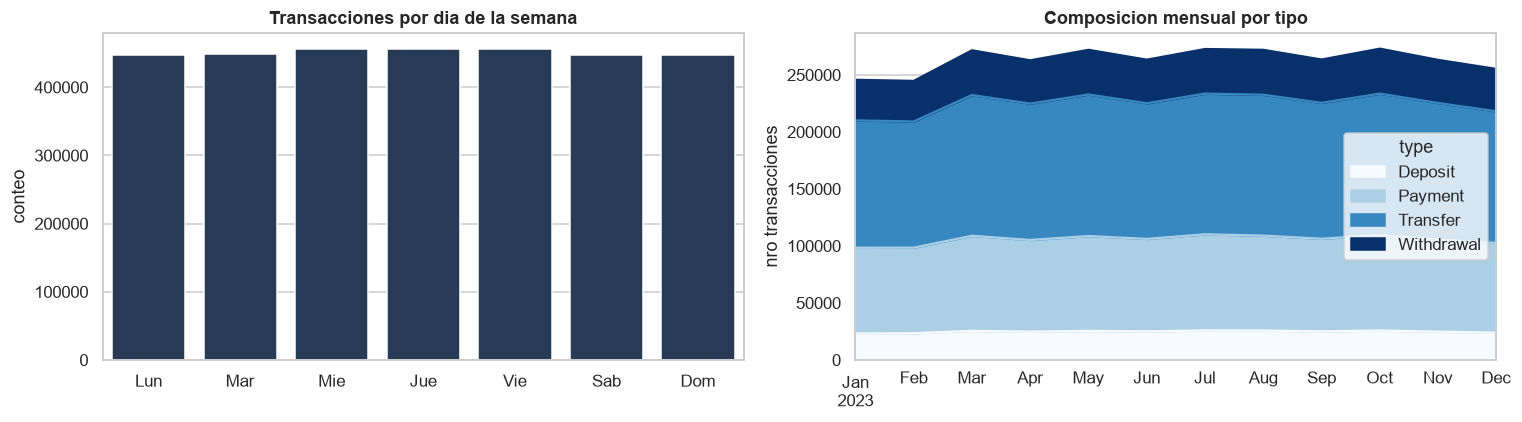

In [34]:
# Patron por dia de la semana y composicion mensual por tipo
dias = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
tx['dow'] = tx['date'].dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
cnt = tx['dow'].value_counts().sort_index()
sns.barplot(x=[dias[i] for i in cnt.index], y=cnt.values, color=AZUL, ax=ax[0])
ax[0].set_title('Transacciones por dia de la semana'); ax[0].set_ylabel('conteo')
comp = tx.groupby(['mes', 'type']).size().unstack(fill_value=0)
comp.plot(kind='area', stacked=True, ax=ax[1], colormap='Blues')
ax[1].set_title('Composicion mensual por tipo'); ax[1].set_ylabel('nro transacciones'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

### 9.1 Agregación por cliente y cruce con la tabla de clientes

Clientes con transacciones: 48,723 de 48,723
Clientes cruzados         : 48,723



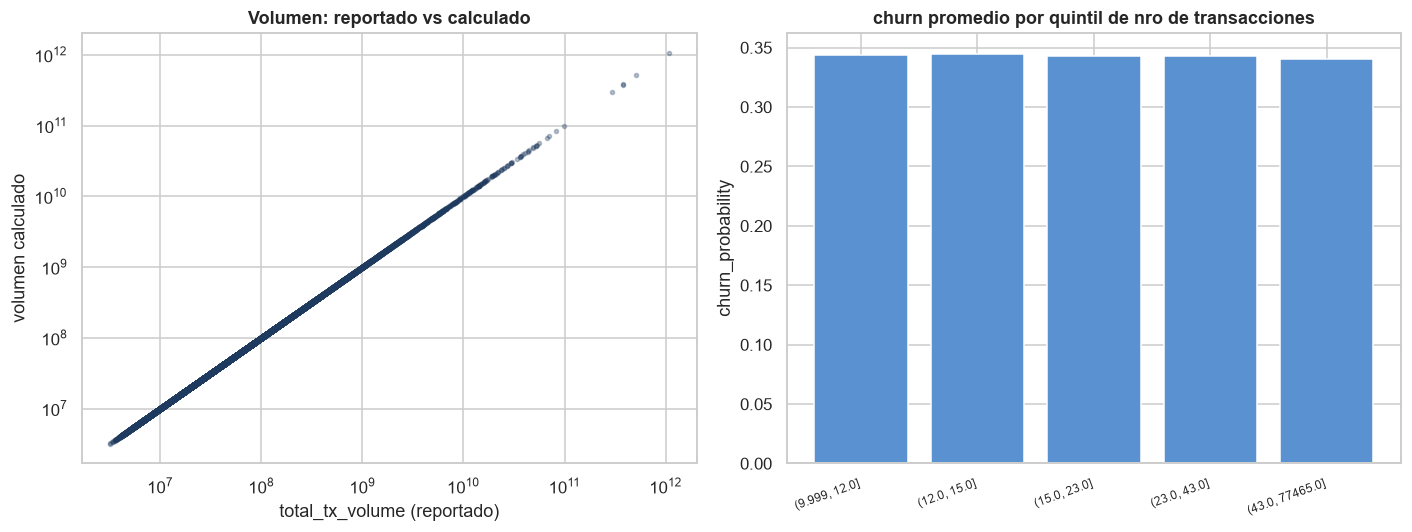

In [35]:
agg = (tx.groupby('customer_id')
         .agg(n_tx=('amount', 'size'), volumen_calc=('amount', 'sum'),
              monto_medio=('amount', 'mean'),
              primera=('date', 'min'), ultima=('date', 'max'))
         .reset_index())
print(f'Clientes con transacciones: {agg.shape[0]:,} de {df.shape[0]:,}')
m = df.merge(agg, on='customer_id', how='inner')
print(f'Clientes cruzados         : {m.shape[0]:,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(m['total_tx_volume'].clip(lower=1), m['volumen_calc'].clip(lower=1),
                s=7, alpha=0.3, color=PAL[0])
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('total_tx_volume (reportado)'); axes[0].set_ylabel('volumen calculado')
axes[0].set_title('Volumen: reportado vs calculado')
m['quintil_ntx'] = pd.qcut(m['n_tx'], 5, duplicates='drop')
g = m.groupby('quintil_ntx', observed=True)['churn_probability'].mean()
axes[1].bar(range(len(g)), g.values, color=PAL[3])
axes[1].set_xticks(range(len(g)))
axes[1].set_xticklabels([str(i) for i in g.index], rotation=20, ha='right', fontsize=8)
axes[1].set_title('churn promedio por quintil de nro de transacciones')
axes[1].set_ylabel('churn_probability')
plt.tight_layout(); plt.show()

### 9.2 Calidad de la tabla de transacciones

In [36]:
print('Filas duplicadas exactas :', int(tx.duplicated().sum()))
print('Montos <= 0              :', int((tx['amount'] <= 0).sum()))
print('Fechas nulas             :', int(tx['date'].isna().sum()))
en_tx = set(tx['customer_id'].unique()); en_cli = set(df['customer_id'].unique())
print(f'Clientes en tx sin perfil: {len(en_tx - en_cli):,}')
print(f'Clientes sin transaccion : {len(en_cli - en_tx):,}')

Filas duplicadas exactas : 102
Montos <= 0              : 0
Fechas nulas             : 0
Clientes en tx sin perfil: 0
Clientes sin transaccion : 0


**Conclusión.** La tabla de transacciones es consistente con la de clientes: no hay clientes huérfanos, montos menores o iguales a cero, ni fechas nulas, y los 48.723 clientes registran actividad. Se detectan 102 filas exactamente duplicadas (0,003 %), volumen despreciable que se elimina por consistencia. Cabe advertir que **el signo de la operación reside solo en el campo `type`**, pues todos los montos son positivos: calcular flujos netos (depósitos − retiros) exigirá aplicar el signo según el tipo.

### 9.3 ¿Qué columna reportada cuadra con las transacciones reales?

In [37]:
real = tx.groupby('customer_id')['amount'].agg(n_real='size', vol_real='sum', avg_real='mean')
mm = df.set_index('customer_id').join(real)

def cuadra(col, ref):
    ok = mm[col].notna() & mm[ref].notna()
    return np.isclose(mm.loc[ok, col].astype(float), mm.loc[ok, ref].astype(float), rtol=0.01).mean() * 100

filas = []
for col, ref in [('tx_count', 'n_real'), ('monthly_transaction_count', 'n_real'),
                 ('total_tx_volume', 'vol_real'), ('total_transaction_volume', 'vol_real'),
                 ('avg_tx_value', 'avg_real'), ('average_transaction_value', 'avg_real')]:
    pct = cuadra(col, ref)
    filas.append([col, ref, round(pct, 1)])
tab_rec = pd.DataFrame(filas, columns=['columna_reportada', 'vs_real', 'coincide_%'])
display(tab_rec)

,columna_reportada,vs_real,coincide_%
0,tx_count,n_real,100.00
1,monthly_transaction_count,n_real,0.10
2,total_tx_volume,vol_real,100.00
3,total_transaction_volume,vol_real,0.40
4,avg_tx_value,avg_real,100.00
5,average_transaction_value,avg_real,1.10


**Conclusión.** La reconciliación es inequívoca y confirma el diagnóstico de la sección 4.2: `tx_count`, `total_tx_volume` y `avg_tx_value` reproducen **exactamente (100 %)** la agregación del detalle transaccional, mientras que sus homólogas del grupo `*_transaction_*` apenas coinciden entre el **0,1 % y el 1,1 %**, porcentaje atribuible a coincidencias fortuitas. **Decisión:** conservar las tres primeras y descartar las tres restantes en el modelado.

**Veredicto por columna:**

| Columna reportada | Coincidencia | Veredicto |
|---|---|---|
| `tx_count` | 100,0 % | **Confiable** |
| `total_tx_volume` | 100,0 % | **Confiable** |
| `avg_tx_value` | 100,0 % | **Confiable** |
| `monthly_transaction_count` | 0,1 % | Descartar |
| `total_transaction_volume` | 0,4 % | Descartar |
| `average_transaction_value` | 1,1 % | Descartar |

**Conclusión (sección 9).** Hay **3,16 M de transacciones de los 48.723 clientes** (todos con actividad), entre enero y diciembre de 2023, y `Transfer` domina (~45 %). El cruce confirma lo detectado en 4.2: **`tx_count` y `total_tx_volume` cuadran con las transacciones reales**, mientras sus gemelas `*_transaction_*` no; son esas gemelas las que hay que descartar. El churn baja en los quintiles de mayor actividad, coherente con la relación productos↔fuga. La **reconciliación (9.3)** lo cuantifica: `tx_count`, `total_tx_volume` y `avg_tx_value` coinciden **100 %** con las transacciones reales, frente a **0,1–1,1 %** de sus gemelas `*_transaction_*` — que son las que se eliminan en el dataset corregido (9.4).

### 9.4 Tabla corregida — dataset depurado para el modelado

In [38]:
# Columnas duplicadas/revueltas a eliminar (segun 4.2 y 9.3)
DROP = ['average_transaction_value', 'total_transaction_volume', 'avg_daily_transactions']
flags = ['has_complaint_topics', 'has_feature_requests', 'has_credit_utilization_ratio']
df_modelo = df.drop(columns=DROP)

resumen_corr = pd.DataFrame({
    'acción': ['Columnas eliminadas (duplicados revueltos)',
               'Banderas añadidas (has_*)',
               'Dimensión resultante (df_modelo)'],
    'detalle': [', '.join(DROP),
                ', '.join(flags),
                f'{df_modelo.shape[0]:,} filas x {df_modelo.shape[1]} columnas']
})
display(resumen_corr)

,acción,detalle
0,Columnas eliminadas (duplicados revueltos),"average_transaction_value, total_transaction_v..."
1,Banderas añadidas (has_*),"has_complaint_topics, has_feature_requests, ha..."
2,Dimensión resultante (df_modelo),"48,723 filas x 54 columnas"


**Conclusión.** El conjunto `df_modelo` queda depurado: sin las columnas transaccionales duplicadas y con las banderas `has_*` que preservan la información de los faltantes estructurales. Los pasos siguientes en la fase de modelado son binarizar `churn` (o plantear la regresión del CLV en escala logarítmica), transformar los montos con log(1+x), codificar las variables categóricas y realizar la partición estratificada con semilla fija.

## 10. Resumen ejecutivo

In [39]:
num = col_num
prod = ['savings_account', 'credit_card', 'personal_loan', 'investment_account',
        'insurance_product', 'bill_payment_user', 'auto_savings_enabled']

print('RESUMEN (datos de clientes)')
print(f'Clientes: {len(df):,}   |   Variables: {df.shape[1]}')
print(f'churn_probability : media {df.churn_probability.mean():.3f}  '
      f'[min {df.churn_probability.min():.2f} , max {df.churn_probability.max():.2f}]')
print(f'CLV               : mediana {df.customer_lifetime_value.median():,.0f}   '
      f'media {df.customer_lifetime_value.mean():,.0f}  (fuerte asimetria)')
print(f'NPS medio         : {df.nps_score.mean():.1f}')
print(f'Satisfaccion media: {df.satisfaction_score.mean():.2f}')
top = df[num].corr()['churn_probability'].drop('churn_probability').abs().sort_values(ascending=False).head(5)
print('\nVariables mas correlacionadas con churn:')
print(df[num].corr()['churn_probability'].loc[top.index].round(3).to_string())
print('\nAdopcion de productos:')
for c in prod: print(f'   {c:22s}: {df[c].mean()*100:5.1f}%')

RESUMEN (datos de clientes)
Clientes: 48,723   |   Variables: 57
churn_probability : media 0.343  [min 0.11 , max 0.50]
CLV               : mediana 129,681,954   media 328,159,671  (fuerte asimetria)
NPS medio         : -26.8
Satisfaccion media: 4.16



Variables mas correlacionadas con churn:
active_products        -0.88
app_logins_frequency   -0.26
age                     0.21
satisfaction_score     -0.18
nps_score              -0.17

Adopcion de productos:
   savings_account       :  78.9%
   credit_card           :  62.5%
   personal_loan         :  31.6%
   investment_account    :  42.6%
   insurance_product     :  21.2%
   bill_payment_user     :  70.1%
   auto_savings_enabled  :  40.1%



### Resumen de correctitud

La auditoría de calidad detectó las **cuatro condiciones** siguientes en estos datos; todas
deben resolverse antes de pasar a la fase de modelado:

| Condición detectada | Evidencia | Sección |
|---|---|---|
| Posible fuga de información en la etiqueta | \|corr(churn, active_products)\| = 0,876 > 0,8 | 7.1 |
| Variable objetivo acotada (no llega a 0 ni a 1) | churn ∈ [0,11 – 0,50] | 4.3 |
| Faltantes concentrados y estructurales | 3 columnas: 50,0 %, 37,5 % y 33,1 % | 4.1 |
| Columnas de transacciones duplicadas o desalineadas | 100 % mismos valores con 0 % de coincidencia por fila | 4.2 y 9.3 |

### Hallazgos principales

**Tamaño y forma.** ~48,7 mil clientes y 54 variables (demografía, productos, *engagement* digital, satisfacción/NPS, resúmenes de transacciones y las dos variables objetivo).

**Posible fuga en la etiqueta.** `churn_probability` está casi determinada por `active_products` (r = −0,876; R² = 0,767) con una relación escalonada, y está acotada a ~0,11–0,50. Parece un *score* construido, no un evento de fuga observado: un modelo que use `active_products` puede verse artificialmente bueno. **Confirmar con quien generó los datos cómo se definió la etiqueta.**

**Columnas de transacciones duplicadas/revueltas.** `avg_tx_value`≡`average_transaction_value` y `total_tx_volume`≡`total_transaction_volume` son la misma variable *revuelta* (idéntica distribución, 0 % de coincidencia por fila). `tx_count`/`total_tx_volume` **sí** cuadran con las transacciones reales; sus gemelas no. Conservar una de cada grupo y descartar la duplicada.

**Faltantes estructurales.** Los NaN de `complaint_topics`, `feature_requests` y `credit_utilization_ratio` significan "no aplica", no "dato perdido". Convertir en banderas `has_*` e imputar con criterio (0 solo donde aplica).

**Asimetría monetaria.** `customer_lifetime_value`, `total_tx_volume` y `avg_tx_value` están muy sesgadas → **transformación logarítmica** antes de modelar. Hay clientes con CLV = 0 por revisar.

**Señal coherente.** Satisfacción, NPS y *engagement* se relacionan con menos churn. El CLV crece de forma ordenada con `clv_segment` y con el volumen transaccionado (ρ de Spearman = 0,98), pero **no** con el número de productos activos.